# Imported and download required libraries

In [323]:
# Data Handling & System Utilities
import os
import random
import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype
import string
import kaggle as kg
from dotenv import load_dotenv
import time

# Data visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import (FuncFormatter, MaxNLocator, PercentFormatter)
import seaborn as sns
import missingno as msno
from IPython.display import (HTML, Markdown, display)

# Interactive visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [324]:
# Statistical analysis and Hypothesis testing
from scipy import stats
from scipy.stats import (gamma, ks_2samp)
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from scipy.stats import norm

# Machine learning & Modeling
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import (LinearRegression, LogisticRegression)
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight


# Model Evaluation Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, 
    classification_report, confusion_matrix, ConfusionMatrixDisplay)
from scipy.stats import ks_2samp
from sklearn.utils.class_weight import compute_class_weight
from yellowbrick.target import ClassBalance

# Calibration analysis
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import brier_score_loss

In [325]:
# Class Imbalance Handling & Resampling Techniques
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler   # Oversampling methods
from imblearn.under_sampling import TomekLinks                        # Undersampling method
from imblearn.combine import SMOTEENN                                 # Hybrid method (over + under)
from imblearn.pipeline import Pipeline                                # Pipeline for chaining resampling steps
from yellowbrick.target import ClassBalance

In [326]:
# Display settings & Warning configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.reset_option('display.max_rows')
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Reset to default after use (recommended practice)
# pd.reset_option('display.max_columns')
import warnings
warnings.filterwarnings("ignore")

# Importing Preprocessed Train and Test dataset

In [327]:
# Define the directory where the data is stored
base_path = r"C:/Users/danie/Downloads/Data Analytic/lending_club_data/preprocessed_data"

try:
    # Attempt to read the specific CSV files
    # We use os.path.join for path safety
    X_train = pd.read_csv(os.path.join(base_path, 'loan_inputs_train.csv'))
    y_train = pd.read_csv(os.path.join(base_path, 'loan_targets_train.csv'))
    X_test = pd.read_csv(os.path.join(base_path, 'loan_inputs_test.csv'))
    y_test = pd.read_csv(os.path.join(base_path, 'loan_targets_test.csv'))
    
except FileNotFoundError:
    print(f"Error: Could not find the files in '{base_path}'.")
    print("Please verify the directory path and ensure the files were exported correctly.")
except Exception as e:
    print(f"An unexpected error occurred during import: {e}")

else:
    # Success confirmation and data verification
    print("Data successfully imported.")
    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"X_test shape:  {X_test.shape}")
    print(f"y_test shape:  {y_test.shape}")

Data successfully imported.
X_train shape: (200000, 37)
y_train shape: (200000, 1)
X_test shape:  (50000, 37)
y_test shape:  (50000, 1)


In [328]:
# Define the directory where the data is stored
base_path = r"C:/Users/danie/Downloads/Data Analytic/lending_club_data/preprocessed_data"

try:
    # Attempt to read the specific CSV files using os.path.join for path safety
    X_train = pd.read_csv(os.path.join(base_path, 'loan_inputs_train.csv'))
    y_train = pd.read_csv(os.path.join(base_path, 'loan_targets_train.csv'))
    X_test = pd.read_csv(os.path.join(base_path, 'loan_inputs_test.csv'))
    y_test = pd.read_csv(os.path.join(base_path, 'loan_targets_test.csv'))
    
except FileNotFoundError:
    print(f"Error: Could not find the files in '{base_path}'.")
    print("Please verify the directory path and ensure the files were exported correctly.")
except Exception as e:
    print(f"An unexpected error occurred during import: {e}")

else:
    # Success confirmation and data verification
    print("Data successfully imported.")
    print("=" * 40)
    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"X_test shape:  {X_test.shape}")
    print(f"y_test shape:  {y_test.shape}")
    print("=" * 40)
    
    # Dataset Previews
    print("\n🚀 X_train preview (first 5 rows):")
    display(X_train.head(5))
    
    print("\n🎯 y_train preview (First 3 rows):")
    display(y_train.head(5))

Data successfully imported.
X_train shape: (200000, 37)
y_train shape: (200000, 1)
X_test shape:  (50000, 37)
y_test shape:  (50000, 1)

🚀 X_train preview (first 5 rows):


,funded_amnt,installment,total_acc,total_rev_hi_lim,CCF,total_rec_int,open_acc,revol_util,mths_since_issue_d,all_util,fico_mean,tot_cur_bal,pub_rec_bankruptcies,pub_rec,mort_acc,int_rate,mo_sin_rcnt_tl,mo_sin_rcnt_rev_tl_op,mths_since_earliest_cr_line,delinq_2yrs,mths_since_last_delinq,annual_inc,inq_fi,inq_last_6mths,recovery_rate,dti,emp_length,term,grade,sub_grade,home_ownership,verification_status,purpose,addr_state,initial_list_status,application_type,int_rate_tier
0,40000.00,902.37,32.00,47500.00,0.87,3916.10,11.00,50.80,17.00,52.00,742.00,169265.00,0.00,0.00,7.00,12.62,2.00,12.00,185.00,0.00,0.00,125000.00,5.00,0.00,0.00,21.20,0.00,60 months,C,C1,MORTGAGE,Verified,Credit card refinancing,NC,w,Individual,M (11 - 17%)
1,6200.00,186.72,17.00,33200.00,0.00,17.41,9.00,37.50,23.00,24.00,737.00,246474.00,1.00,1.00,2.00,5.32,12.00,12.00,267.00,0.00,0.00,85165.00,1.00,0.00,0.00,15.02,5.00,36 months,A,A1,MORTGAGE,Source Verified,Other,TX,w,Individual,L (5 - 11%)
2,6000.00,193.41,18.00,44900.00,0.45,790.10,10.00,23.10,22.00,23.00,752.00,10351.00,0.00,0.00,1.00,9.93,14.00,14.00,431.00,0.00,0.00,13992.00,1.00,0.00,0.00,25.90,10.00,36 months,B,B2,OWN,Not Verified,Credit card refinancing,FL,f,Individual,L (5 - 11%)
3,14400.00,342.96,44.00,22200.00,0.84,2169.39,15.00,32.30,15.00,30.00,682.00,111725.00,0.00,0.00,4.00,15.05,7.00,7.00,252.00,3.00,11.00,275000.00,4.00,0.00,0.00,17.40,4.00,60 months,C,C4,MORTGAGE,Not Verified,Credit card refinancing,VA,w,Individual,M (11 - 17%)
4,16000.00,351.00,25.00,43300.00,0.70,2876.26,7.00,18.60,24.00,19.00,737.00,216045.00,0.00,0.00,2.00,11.39,6.00,17.00,397.00,1.00,10.00,72000.00,0.00,0.00,0.00,33.97,0.00,60 months,B,B3,MORTGAGE,Not Verified,Major purchase,GA,w,Individual,M (11 - 17%)



🎯 y_train preview (First 3 rows):


,target
0,1.00
1,0.00
2,0.00
3,0.00
4,0.00


In [329]:
# Define columns to remove
cols_to_drop = ['total_rec_int', 'inq_fi', 'addr_state', 'CCF', 'recovery_rate']

# Create a dictionary to iterate through splits and their names
splits = {'Training': X_train, 'Testing': X_test}

print("🚀 Starting column removal...")

for name, df in splits.items():
    # Drop columns and update the dataframe in-place
    df.drop(columns=cols_to_drop, errors='ignore', inplace=True)
    
    # Verification: Check if columns still exist in the dataframe
    remaining_forbidden = [col for col in cols_to_drop if col in df.columns]
    
    if not remaining_forbidden:
        print(f"✅ {name} set: {cols_to_drop} successfully removed. (Remaining columns: {len(df.columns)})")
    else:
        print(f"❌ {name} set: Failed to remove {remaining_forbidden}")

# Final check
print(f"\nFinal Feature List (X_train): {X_train.columns.tolist()}")
print(f"\nFinal Feature List (X_test): {X_test.columns.tolist()}")

🚀 Starting column removal...
✅ Training set: ['total_rec_int', 'inq_fi', 'addr_state', 'CCF', 'recovery_rate'] successfully removed. (Remaining columns: 32)
✅ Testing set: ['total_rec_int', 'inq_fi', 'addr_state', 'CCF', 'recovery_rate'] successfully removed. (Remaining columns: 32)

Final Feature List (X_train): ['funded_amnt', 'installment', 'total_acc', 'total_rev_hi_lim', 'open_acc', 'revol_util', 'mths_since_issue_d', 'all_util', 'fico_mean', 'tot_cur_bal', 'pub_rec_bankruptcies', 'pub_rec', 'mort_acc', 'int_rate', 'mo_sin_rcnt_tl', 'mo_sin_rcnt_rev_tl_op', 'mths_since_earliest_cr_line', 'delinq_2yrs', 'mths_since_last_delinq', 'annual_inc', 'inq_last_6mths', 'dti', 'emp_length', 'term', 'grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'initial_list_status', 'application_type', 'int_rate_tier']

Final Feature List (X_test): ['funded_amnt', 'installment', 'total_acc', 'total_rev_hi_lim', 'open_acc', 'revol_util', 'mths_since_issue_d', 'all_util', 'fico_mean

# Re-inspect the dataset

In [330]:
def compute_data_audit_summary(df_input, dataset_name="Dataset"):
    """
    Computes data types, missing value counts, and missing percentages 
    for columns that contain missing data.
    """
    summary = (
        df_input.dtypes.to_frame(name="Type")
        .join(pd.DataFrame({
            "Missing values": df_input.isna().sum(),
            "Percentage Missing": round(df_input.isna().mean() * 100, 2)
        }))
        # Filter to only keep columns that have 1 or more missing values
        .loc[lambda df: df["Missing values"] > 0]
        # Sort by the highest number of missing values
        .sort_values(by="Missing values", ascending=False))
    
    return summary

# Lits all columns with missing values (Train)
print("\n📝 X_TRAIN: All columns with missing values")
print("-" * 100)
X_train_summary = compute_data_audit_summary(X_train, "X_train")
display(X_train_summary) 

# Lits all columns with missing values (Test)
print("\n📝 X_TEST: All columns with missing values")
print("-" * 100)
X_test_summary = compute_data_audit_summary(X_test, "X_test")
display(X_test_summary)


📝 X_TRAIN: All columns with missing values
----------------------------------------------------------------------------------------------------


,Type,Missing values,Percentage Missing
all_util,float64,42,0.02



📝 X_TEST: All columns with missing values
----------------------------------------------------------------------------------------------------


,Type,Missing values,Percentage Missing
all_util,float64,13,0.03


In [331]:
# Fill missing values with 0
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# Verify remaining missing values
print("\nRemaining missing values in X_train:")
print(X_train.isna().sum().sum())

print("\nRemaining missing values in X_test:")
print(X_test.isna().sum().sum())


Remaining missing values in X_train:
0

Remaining missing values in X_test:
0


In [332]:
# Combine training features (X_train) and target (y_train) into one trained dataset for reference
train_data = pd.concat([X_train, y_train], axis=1)

In [333]:
# Combine training features (X_train) and target (y_train) into one trained dataset for reference
test_data = pd.concat([X_test, y_test], axis=1)

# Prevents dummy variable trap (perfect multicollinearity)

In [334]:
# Identify numerical and categorical columns
numerical_columns = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# Informative, structured breakdowns
print("\n🔎 DETAILED COLUMN BREAKDOWNS")
print("-" * 65)

print(f"🔢 NUMERICAL FEATURES ({len(numerical_columns)}):")
if numerical_columns:
    # Prints features in a neat, comma-separated block rather than a single giant list line
    print(", ".join(f"'{col}'" for col in numerical_columns))
else:
    print("  (None found)")

print(f"\n🔤 CATEGORICAL FEATURES ({len(categorical_columns)}):")
if categorical_columns:
    print(", ".join(f"'{col}'" for col in categorical_columns))
else:
    print("  (None found)")
print("-" * 65)


🔎 DETAILED COLUMN BREAKDOWNS
-----------------------------------------------------------------
🔢 NUMERICAL FEATURES (23):
'funded_amnt', 'installment', 'total_acc', 'total_rev_hi_lim', 'open_acc', 'revol_util', 'mths_since_issue_d', 'all_util', 'fico_mean', 'tot_cur_bal', 'pub_rec_bankruptcies', 'pub_rec', 'mort_acc', 'int_rate', 'mo_sin_rcnt_tl', 'mo_sin_rcnt_rev_tl_op', 'mths_since_earliest_cr_line', 'delinq_2yrs', 'mths_since_last_delinq', 'annual_inc', 'inq_last_6mths', 'dti', 'emp_length'

🔤 CATEGORICAL FEATURES (9):
'term', 'grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'initial_list_status', 'application_type', 'int_rate_tier'
-----------------------------------------------------------------


In [335]:
# One-hot encode categorical variables
X_train_encoded = pd.get_dummies(X_train, columns=categorical_columns, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_columns, drop_first=True)

# Align columns across Train, Test, AND Holdout to ensure consistency
# Alternatively: X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)
X_train_cols = X_train_encoded.columns
X_test_encoded = X_test_encoded.reindex(columns=X_train_cols, fill_value=0)

In [336]:
# Shape and Column Alignment Check
def check_alignment(df_train, df_test):
    train_cols = set(df_train.columns)
    test_cols = set(df_test.columns)

    is_aligned = (train_cols == test_cols)
    print(f"✅ All Columns Aligned: {is_aligned}")
    print(f"Shape - Train: {df_train.shape}, Test: {df_test.shape}")
    
    if not is_aligned:
        missing_test = train_cols - test_cols
        print(f"⚠️ Missing in Test: {missing_test}")

check_alignment(X_train_encoded, X_test_encoded)

✅ All Columns Aligned: True
Shape - Train: (200000, 84), Test: (50000, 84)


In [337]:
# Inspect the trained data set after alignment
X_train_encoded.head()

,funded_amnt,installment,total_acc,total_rev_hi_lim,open_acc,revol_util,mths_since_issue_d,all_util,fico_mean,tot_cur_bal,pub_rec_bankruptcies,pub_rec,mort_acc,int_rate,mo_sin_rcnt_tl,mo_sin_rcnt_rev_tl_op,mths_since_earliest_cr_line,delinq_2yrs,mths_since_last_delinq,annual_inc,inq_last_6mths,dti,emp_length,term_ 60 months,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,sub_grade_A2,sub_grade_A3,sub_grade_A4,sub_grade_A5,sub_grade_B1,sub_grade_B2,sub_grade_B3,sub_grade_B4,sub_grade_B5,sub_grade_C1,sub_grade_C2,sub_grade_C3,sub_grade_C4,sub_grade_C5,sub_grade_D1,sub_grade_D2,sub_grade_D3,sub_grade_D4,sub_grade_D5,sub_grade_E1,sub_grade_E2,sub_grade_E3,sub_grade_E4,sub_grade_E5,sub_grade_F1,sub_grade_F2,sub_grade_F3,sub_grade_F4,sub_grade_F5,sub_grade_G1,sub_grade_G2,sub_grade_G3,sub_grade_G4,sub_grade_G5,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,verification_status_Source Verified,verification_status_Verified,purpose_Car financing,purpose_Credit card refinancing,purpose_Debt consolidation,purpose_Green loan,purpose_Home buying,purpose_Home improvement,purpose_Major purchase,purpose_Medical expenses,purpose_Moving and relocation,purpose_Other,purpose_Vacation,initial_list_status_w,application_type_Joint App,int_rate_tier_L (5 - 11%),int_rate_tier_M (11 - 17%)
0,40000.00,902.37,32.00,47500.00,11.00,50.80,17.00,52.00,742.00,169265.00,0.00,0.00,7.00,12.62,2.00,12.00,185.00,0.00,0.00,125000.00,0.00,21.20,0.00,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True
1,6200.00,186.72,17.00,33200.00,9.00,37.50,23.00,24.00,737.00,246474.00,1.00,1.00,2.00,5.32,12.00,12.00,267.00,0.00,0.00,85165.00,0.00,15.02,5.00,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False
2,6000.00,193.41,18.00,44900.00,10.00,23.10,22.00,23.00,752.00,10351.00,0.00,0.00,1.00,9.93,14.00,14.00,431.00,0.00,0.00,13992.00,0.00,25.90,10.00,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
3,14400.00,342.96,44.00,22200.00,15.00,32.30,15.00,30.00,682.00,111725.00,0.00,0.00,4.00,15.05,7.00,7.00,252.00,3.00,11.00,275000.00,0.00,17.40,4.00,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True
4,16000.00,351.00,25.00,43300.00,7.00,18.60,24.00,19.00,737.00,216045.00,0.00,0.00,2.00,11.39,6.00,17.00,397.00,1.00,10.00,72000.00,0.00,33.97,0.00,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True


# Standardized data (Scaling)

Standardizes numerical features using:
$$z = \frac{x - \mu}{\sigma}$$

`scaler.fit_transform()` on training data:
- Computes the training sample mean ($\mu$) and standard deviation ($\sigma$)
- Then transforms (scales) the training data using those values. (Mean of 0 and Standard Deviation of 1)

`scaler.transform()` on test data:
- The test data is scaled using the mean and standard deviation that were computed from the training set.
- The test set’s own statistics are never used.

**Golden Rule:** Never call `.fit()` or `.fit_transform()` on test or validation data. Doing so leaks future data distributions into model pipeline, invalidating the performance metrics (model must remain completely blind to the test set until prediction time.)

In [338]:
# Standardize numerical features
# fit_transform on Train; transform only on Test to prevent data leakage
scaler = StandardScaler()
X_train_encoded[numerical_columns] = scaler.fit_transform(X_train_encoded[numerical_columns])
X_test_encoded[numerical_columns] = scaler.transform(X_test_encoded[numerical_columns])

In [339]:
# Textual Metric audit
def print_scaling_metrics(df_train, df_test, features):
    """Calculates and displays a text-based statistical audit table per feature."""
    for col in features:
        scaling_df = pd.DataFrame({
            'Metric': ['Mean', 'Std Dev', 'Min', 'Max'],
            'Train Set': [df_train[col].mean(), df_train[col].std(ddof=0), df_train[col].min(), df_train[col].max()],
            'Test Set':  [df_test[col].mean(),  df_test[col].std(ddof=0),  df_test[col].min(),  df_test[col].max()]
        }).round(4)
        
        print(f"\n🧪 Scaling Audit for Feature: '{col}'")
        display(scaling_df)
        print("="*45)

# Visual audit plotting
def plot_scaling_distributions(df_train, df_test, features, figsize_per_row=(20, 5.0)):
    """Generates a clean dual-plot distribution and outlier grid for the features."""
    sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#fcfcfc", "grid.color": "#d9d9d9"})
    
    # Palette configuration for train and test
    c_tr, c_te, kde_tr, kde_te, c_norm = "#3B82F6", "#F97316", "#1D4ED8", "#EA580C", "#6b7280"
    num_feats = len(features)
    
    fig, axes = plt.subplots(num_feats, 2, figsize=(figsize_per_row[0], figsize_per_row[1] * num_feats), gridspec_kw={"wspace": 0.28, "hspace": 0.48})
    axes = np.expand_dims(axes, axis=0) if num_feats == 1 else axes

    for i, col in enumerate(features):
        ax_dist, ax_box = axes[i, 0], axes[i, 1]

        # Histograms & Normal Curve
        sns.histplot(df_train[col], color=c_tr, label="Train", kde=True, stat="density", alpha=0.5, bins=35, ax=ax_dist, line_kws={"linewidth": 2.5, "color": kde_tr})
        sns.histplot(df_test[col], color=c_te, label="Test", kde=True, stat="density", alpha=0.45, bins=35, ax=ax_dist, line_kws={"linewidth": 2.5, "color": kde_te})
        
        x_axis = np.linspace(*ax_dist.get_xlim(), 200)
        ax_dist.plot(x_axis, norm.pdf(x_axis, 0, 1), color=c_norm, linestyle=":", linewidth=2.3, label="Ideal Normal (0,1)")
        ax_dist.axvline(df_train[col].mean(), color=kde_tr, linestyle="--", linewidth=1.8, label=f"Train μ ({df_train[col].mean():.2f})")
        ax_dist.axvline(df_test[col].mean(), color=kde_te, linestyle="--", linewidth=1.8, label=f"Test μ ({df_test[col].mean():.2f})")
        
        # Split title out into set_title to handle bold weighting
        ax_dist.set_title(f"Distribution & Alignment: {col}", fontweight="bold")
        ax_dist.set(xlabel="Standard Deviations from Mean", ylabel="Density")

        # Boxplots
        comb_df = pd.concat([pd.DataFrame({"V": df_train[col], "D": "Train"}), pd.DataFrame({"V": df_test[col], "D": "Test"})])
        sns.boxplot(data=comb_df, x="V", y="D", palette=[c_tr, c_te], width=0.5, linewidth=1.3, fliersize=4, ax=ax_box, boxprops={"alpha": 0.78}, medianprops={"color": "black", "linewidth": 2})
        ax_box.axvline(0, color=c_norm, linestyle="-.", linewidth=1.5, alpha=0.7)
        
        # Split title out into set_title to handle bold weighting
        ax_box.set_title(f"Quartile & Outlier Spread: {col}", fontweight="bold")
        ax_box.set(xlabel="Standard Deviations from Mean", ylabel="")

    # Global Legend Integration
    handles, labels = ax_dist.get_legend_handles_labels()
    legend = fig.legend(handles, labels, loc="lower center", ncol=5, fontsize=10, bbox_to_anchor=(0.5, -0.01), frameon=True, fancybox=True, shadow=True, borderpad=0.8)
    legend.get_frame().set_edgecolor("#b0b0b0")
    legend.get_frame().set_linewidth(1.2)
    legend.get_frame().set_facecolor("white")
    legend.get_frame().set_alpha(0.96)
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.show()


🧪 Scaling Audit for Feature: 'funded_amnt'


,Metric,Train Set,Test Set
0,Mean,0.00,-0.01
1,Std Dev,1.00,0.99
2,Min,-1.46,-1.46
3,Max,2.48,2.48



🧪 Scaling Audit for Feature: 'installment'


,Metric,Train Set,Test Set
0,Mean,-0.00,-0.01
1,Std Dev,1.00,0.99
2,Min,-1.49,-1.49
3,Max,4.43,4.07



🧪 Scaling Audit for Feature: 'total_acc'


,Metric,Train Set,Test Set
0,Mean,-0.00,-0.01
1,Std Dev,1.00,1.00
2,Min,-1.74,-1.74
3,Max,10.64,11.80


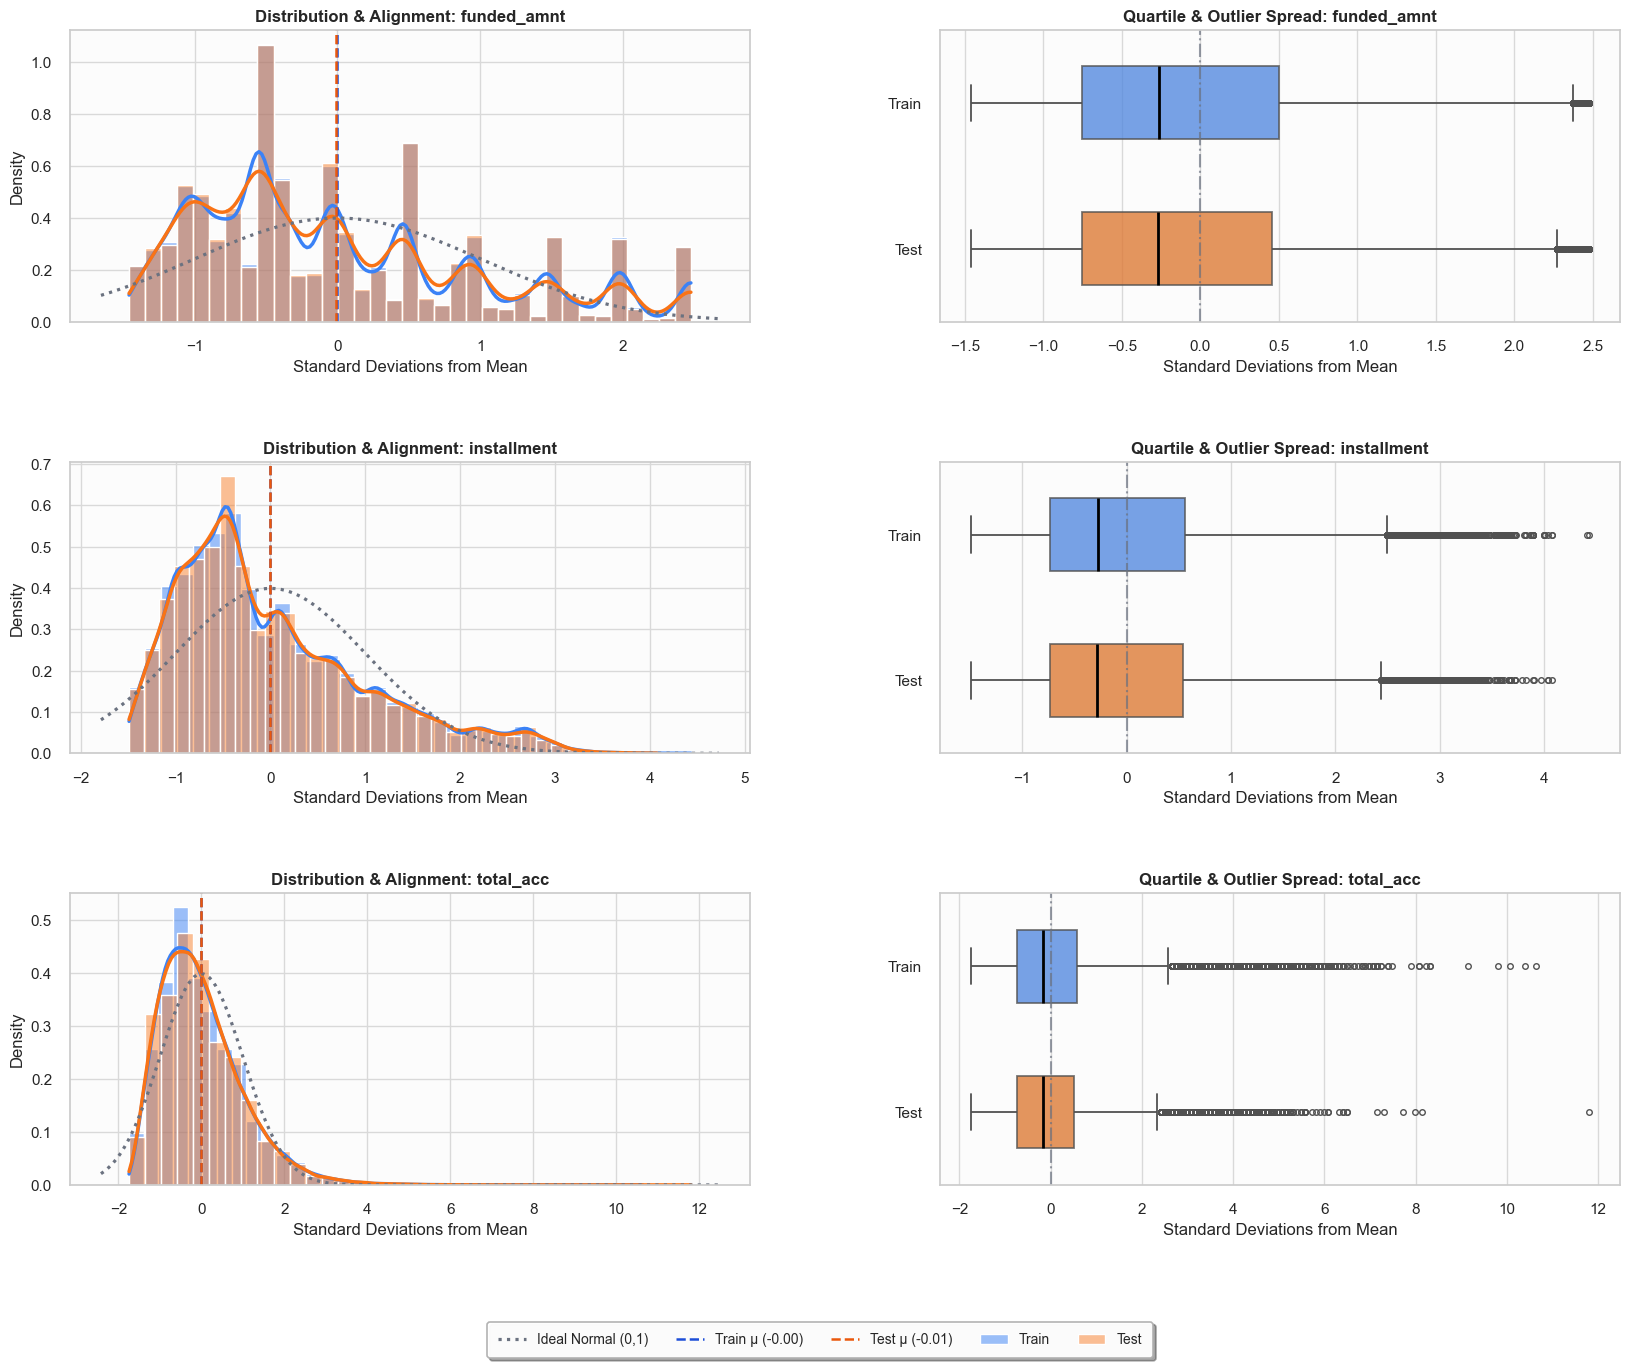

In [340]:
# Target the columns you wish to evaluate
features_to_audit = numerical_columns[:3]

# Run Textual audit
print_scaling_metrics(X_train_encoded, X_test_encoded, features_to_audit)

# Run Visualization plots
plot_scaling_distributions(X_train_encoded, X_test_encoded, features_to_audit)

# Checking for Class Imbalance in the Fully Preprocessed Dataset

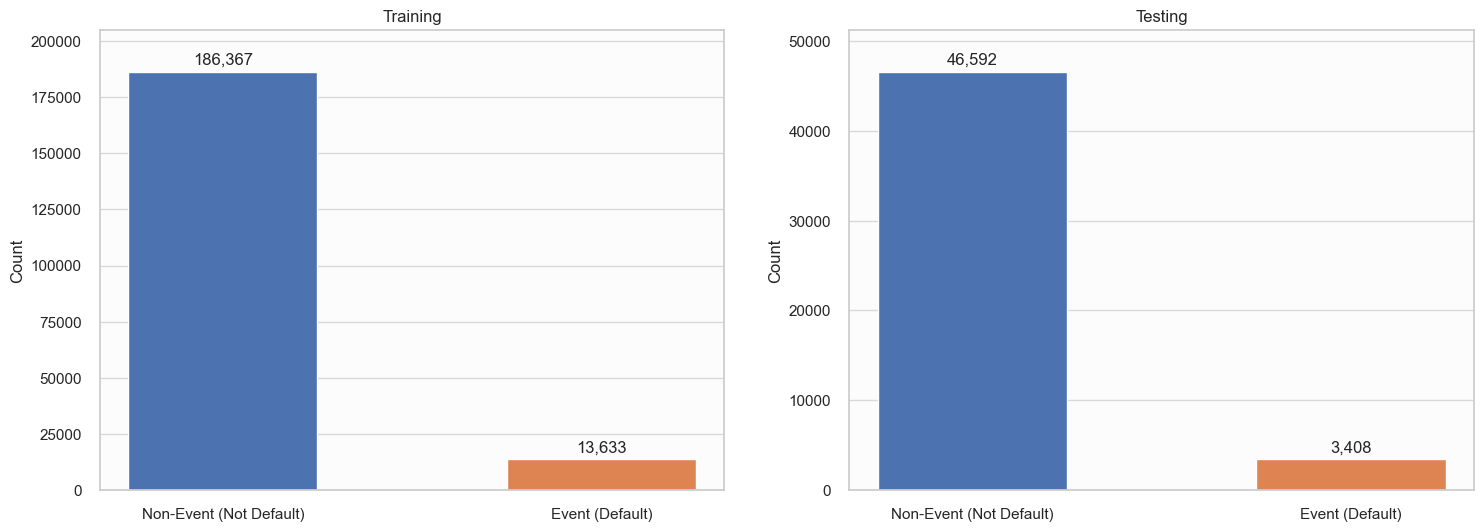

In [341]:
# Create 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Define the sets and titles
datasets = [(y_train, "Training"), (y_test, "Testing")]

# Loop through each dataset and plot it
for i, (data, title) in enumerate(datasets):
    # Convert the target variable to a 1D array (required by ClassBalance to avoid errors)
    data_1d = data.values.ravel() 
    
    # Initialize visualizer
    visualizer = ClassBalance(labels=["Non-Event (Not Default)", "Event (Default)"], ax=axes[i])
    
    # Fit the data and draw the class distribution bars
    visualizer.fit(data_1d)
    
    # Finalize to map the text labels ("Non-Event", "Event") to the axis
    visualizer.finalize() 

    # Change the y-axis label to "Count" for clarity
    axes[i].set_ylabel("Count")
    
    # Add the actual count numbers on top of each bar
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='{:,.0f}', padding=3)
    
    axes[i].set_title(title)

# Add some extra padding at the top of the y-axis so the labels don't hit the ceiling
plt.tight_layout()
plt.subplots_adjust(top=0.85, wspace=0.2) 
plt.show()

From the chart above, we see the events classified as defaults have very few observations. This class imbalance can affect our model while training. To solve this problem, we will oversample the minority class.

# Oversampling Minority Class to Resolve Class Imbalance

In [342]:
# Define strategies
y_train_flat = np.ravel(y_train)
y_test_flat = np.ravel(y_test)

strategies = {
    "Class Weight": "class_weight",
    "Random Over Sampling": RandomOverSampler(random_state=42),
    "SMOTE": SMOTE(random_state=42, k_neighbors=5)}

# Store result and loop through methods
# ---------------------------------------------------------------------------------------------------
results = []
for name, method in strategies.items():
    print(f"\nProcessing: {name}")
    start_time = time.time()

    # Class weight 
    if method == "class_weight":
        X_resampled = X_train_encoded
        y_resampled = y_train_flat
        logit = LogisticRegression(class_weight="balanced", solver="saga", max_iter=100, n_jobs=-1, random_state=42)

    # ROS and SMOTE
    else:
        X_resampled, y_resampled = method.fit_resample(X_train_encoded, y_train_flat)
        logit = LogisticRegression(solver="saga", max_iter=100, n_jobs=-1, random_state=42)

    # Model fitting
    # -----------------------------------------------------------------------------------------------
    logit.fit(X_resampled, y_resampled)

    # Probabilities predictions for the positive class (default)
    y_pred_proba = logit.predict_proba(X_test_encoded)[:, 1]

    # YOUDEN threshold
    fpr, tpr, thresholds = roc_curve(y_test_flat, y_pred_proba)
    youden_index = tpr - fpr
    best_idx = np.argmax(youden_index)
    optimal_threshold = thresholds[best_idx]
    y_pred = (y_pred_proba >= optimal_threshold).astype(int)

    # Processing time calculation
    compute_time = time.time() - start_time

    # Store results
    # -----------------------------------------------------------------------------------------------
    results.append({
        "Method": name,
        "Compute Time (sec)": round(compute_time, 2),
        "Optimal Threshold": round(optimal_threshold, 4),
        "Youden's Index": round(youden_index[best_idx], 4),
        "ROC-AUC": round(roc_auc_score(y_test_flat, y_pred_proba), 4),
        "Test F1-Score": round(f1_score(y_test_flat, y_pred), 4),
        "Test Recall": round(recall_score(y_test_flat, y_pred), 4),
        "Test Precision": round(precision_score(y_test_flat, y_pred), 4),
        "Train Size": len(y_resampled),
        "Event Count (Train)": int(np.sum(y_resampled))})

# Preview results in a DataFrame
# -----------------------------------------------------------------------------------------------
comparison_df = pd.DataFrame(results)
comparison_df["Method"] = pd.Categorical(comparison_df["Method"], categories=list(strategies.keys()), ordered=True)
comparison_df = comparison_df.sort_values(by="Method")

print("\n IMBALANCE HANDLING COMPARISON")
print("-" * 130)

display(comparison_df.style.set_caption("Comparison of Class Weight, Random Over Sampling and SMOTE")
    .background_gradient(subset=["ROC-AUC", "Test F1-Score", "Test Recall", "Youden's Index"], cmap="YlGn"))


Processing: Class Weight

Processing: Random Over Sampling

Processing: SMOTE

 IMBALANCE HANDLING COMPARISON
----------------------------------------------------------------------------------------------------------------------------------


,Method,Compute Time (sec),Optimal Threshold,Youden's Index,ROC-AUC,Test F1-Score,Test Recall,Test Precision,Train Size,Event Count (Train)
0,Class Weight,34.360000,0.498200,0.397300,0.766600,0.234600,0.721000,0.140100,200000,13633
1,Random Over Sampling,61.340000,0.433000,0.398300,0.767200,0.218100,0.808100,0.126100,372734,186367
2,SMOTE,66.750000,0.283100,0.352600,0.735000,0.208600,0.751200,0.121100,372734,186367


In [343]:
# Class weighting details
# -----------------------------------------------------------------------------------------------
class_counts = (pd.Series(y_train.values.ravel()).value_counts().sort_index())
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train.values.ravel())

# Summary table for class distribution and weights
class_weight_summary = pd.DataFrame({
    "Class": ["Non-Event (Not Default)", "Event (Default)"],
    "Count": class_counts.values,
    "Class Weight": np.round(weights, 4)})

print("TRAINING CLASS DISTRIBUTION & CLASS WEIGHTS")
print("-" * 100)
display(class_weight_summary)

TRAINING CLASS DISTRIBUTION & CLASS WEIGHTS
----------------------------------------------------------------------------------------------------


,Class,Count,Class Weight
0,Non-Event (Not Default),186367,0.54
1,Event (Default),13633,7.34


🏦 CLASS DISTRIBUTION BEFORE AND AFTER RANDOM OVER SAMPLING
---------------------------------------------------------------------------


,Before ROS,After ROS
Non-Event (Not Default),186367,186367
Event (Default),13633,186367


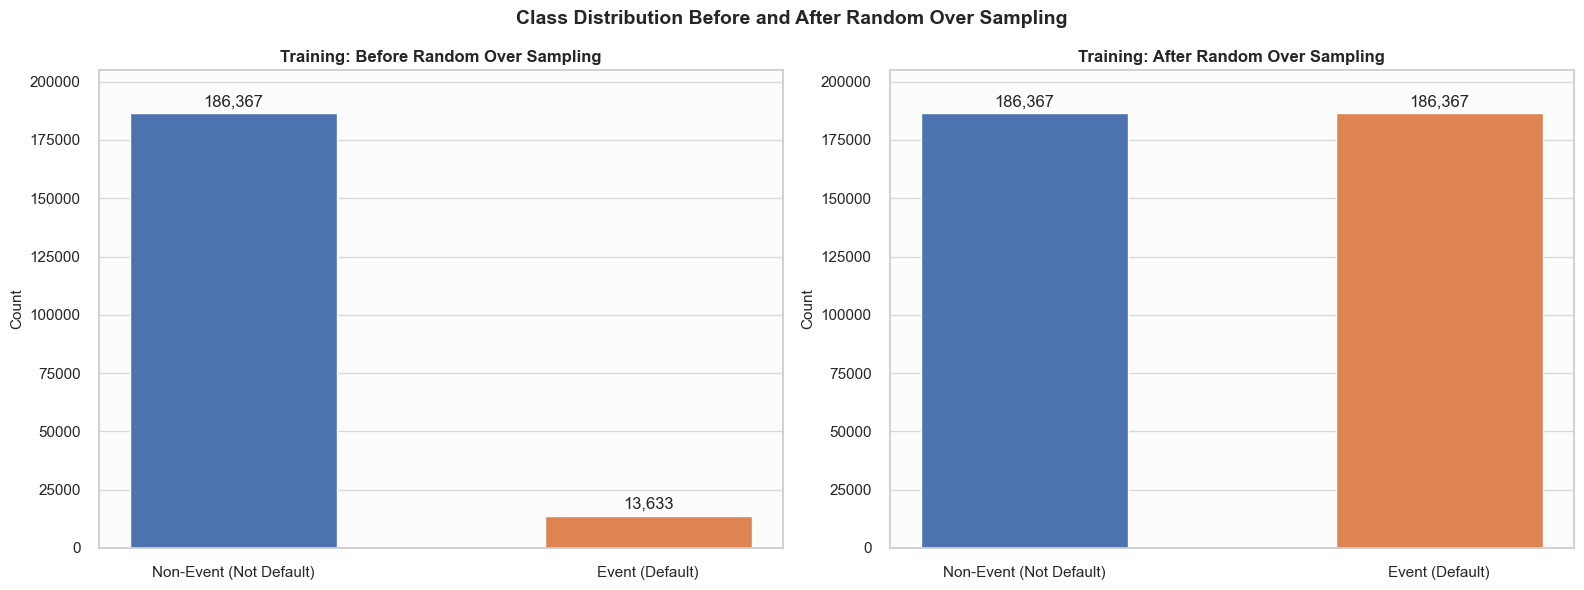

In [344]:
# Random over sampling details
# -----------------------------------------------------------------------------------------------
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train_encoded, y_train.values.ravel())

# Class distribution summary table
before_counts = pd.Series(y_train.values.ravel()).value_counts().sort_index()
after_counts = pd.Series(y_ros).value_counts().sort_index()

distribution_table = pd.DataFrame({
    "Before ROS": before_counts,
    "After ROS": after_counts})

distribution_table.index = [
    "Non-Event (Not Default)",
    "Event (Default)"]

print("🏦 CLASS DISTRIBUTION BEFORE AND AFTER RANDOM OVER SAMPLING")
print("-" * 75)

display(distribution_table)

# Visualization of class distribution before and after random over sampling
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_data = [
    (y_train.values.ravel(),"Training: Before Random Over Sampling"),
    (y_ros, "Training: After Random Over Sampling")]

for i, (data, title) in enumerate(plot_data):
    visualizer = ClassBalance(labels=["Non-Event (Not Default)", "Event (Default)"], ax=axes[i])
    visualizer.fit(data)
    visualizer.finalize()

    axes[i].set_title(title, fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Count", fontsize=11)
    # Add count labels above bars
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='{:,.0f}', padding=3)

plt.suptitle("Class Distribution Before and After Random Over Sampling", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

# Building PD Model (White-box)

| Purpose                   | Dataset               |
| ------------------------- | --------------------- |
| Model fitting             | X_train + y_train     |
| Model validation          | X_test + y_test       |

## Logistic Regression (Class Weighting)

In [345]:
# Train class-weighted logistic regression
# -----------------------------------------------------------------------------------------------
logit_cw = LogisticRegression(class_weight='balanced', solver='saga', max_iter=100, n_jobs=-1, random_state=42)
logit_cw.fit(X_train_encoded, y_train.values.ravel())

# Predict event (default) probabilities
# -----------------------------------------------------------------------------------------------
cw_y_pred_proba = logit_cw.predict_proba(X_test_encoded)[:, 1]

# FInd optimal threshold that maximizes the difference between TPR and FPR (Youden's Index)
# -----------------------------------------------------------------------------------------------
cw_false_positive_rate, cw_true_positive_rate, cw_thresholds = roc_curve(y_test, cw_y_pred_proba)
cw_youden_index = (cw_true_positive_rate - cw_false_positive_rate)
cw_optimal_idx = np.argmax(cw_youden_index)
cw_optimal_threshold = float(cw_thresholds[cw_optimal_idx])

# Apply optimal threshold to get final class predictions
cw_y_pred = (cw_y_pred_proba >= cw_optimal_threshold).astype(int)

# Model performance summary table
# -----------------------------------------------------------------------------------------------
performance_summary = pd.DataFrame({
    "Metric": ["Optimal Threshold", "Youden's Index", "ROC-AUC", "F1 Score", "Recall", "Precision"],
    "Value": [
        round(cw_optimal_threshold, 4),
        round(cw_youden_index[cw_optimal_idx], 4),
        round(roc_auc_score(y_test, cw_y_pred_proba), 4),
        round(f1_score(y_test, cw_y_pred), 4),
        round(recall_score(y_test, cw_y_pred), 4),
        round(precision_score(y_test, cw_y_pred), 4)]})

print("CLASS-WEIGHTED LOGISTIC REGRESSION PERFORMANCE")
print("-" * 100)

display(performance_summary)

print(f"\n Classification Report (Test Set) - Threshold = {cw_optimal_threshold:.4f}")
print("-" * 100)

print(classification_report(y_test, cw_y_pred, target_names=["Non-Event (Not Default)", "Event (Default)"], digits=4))

CLASS-WEIGHTED LOGISTIC REGRESSION PERFORMANCE
----------------------------------------------------------------------------------------------------


,Metric,Value
0,Optimal Threshold,0.50
1,Youden's Index,0.40
2,ROC-AUC,0.77
3,F1 Score,0.23
4,Recall,0.72
5,Precision,0.14



 Classification Report (Test Set) - Threshold = 0.4982
----------------------------------------------------------------------------------------------------
                         precision    recall  f1-score   support

Non-Event (Not Default)     0.9707    0.6763    0.7972     46592
        Event (Default)     0.1401    0.7210    0.2346      3408

               accuracy                         0.6794     50000
              macro avg     0.5554    0.6986    0.5159     50000
           weighted avg     0.9141    0.6794    0.7589     50000



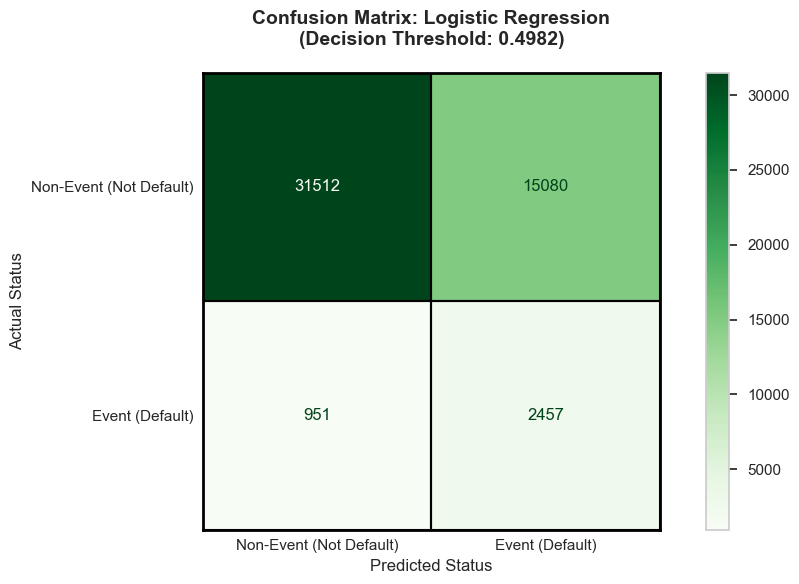

In [346]:
# Create the figure and axis object
fig, ax = plt.subplots(figsize=(10, 6))

# Compute the confusion matrix values
cm_cw = confusion_matrix(y_test, cw_y_pred)

# Display confusion matrix with green color map
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cw, 
    display_labels=["Non-Event (Not Default)", "Event (Default)"])

# Plot the matrix
disp.plot(cmap='Greens', ax=ax, colorbar=True)

# Remove default grid
ax.grid(False)

# Add clear borders around each cell
for i in range(cm_cw.shape[0]):
    for j in range(cm_cw.shape[1]):
        ax.add_patch(
            plt.Rectangle(
                (j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='black', linewidth=1.5))

# Add strong outer border (spines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)       # thickness of border
    spine.set_edgecolor('black') # color of border

# Title and Formatting
plt.title(f"Confusion Matrix: Logistic Regression\n(Decision Threshold: {cw_optimal_threshold:.4f})", pad=20, fontsize=14, fontweight='bold')

# Add clear axis labels
plt.xlabel("Predicted Status", fontsize=12)
plt.ylabel("Actual Status", fontsize=12)
ax.tick_params(axis='both', which='both', length=0)
plt.tight_layout()
plt.show()

Visualize the trade-off between precision and recall, with particular focus on their intersection point. The approach is adapted from the methodology discussed in the following reference:

https://medium.com/@pacosun/precision-and-recall-are-fighting-for-your-models-soul-eef30a8a459c

PRECISION–RECALL INTERSECTION ANALYSIS
----------------------------------------------------------------------------------------------------
Intersection Threshold : 0.7672


,Metric,Value
0,Intersection Threshold,0.77
1,Precision,0.24
2,Recall,0.24
3,F1 Score,0.24


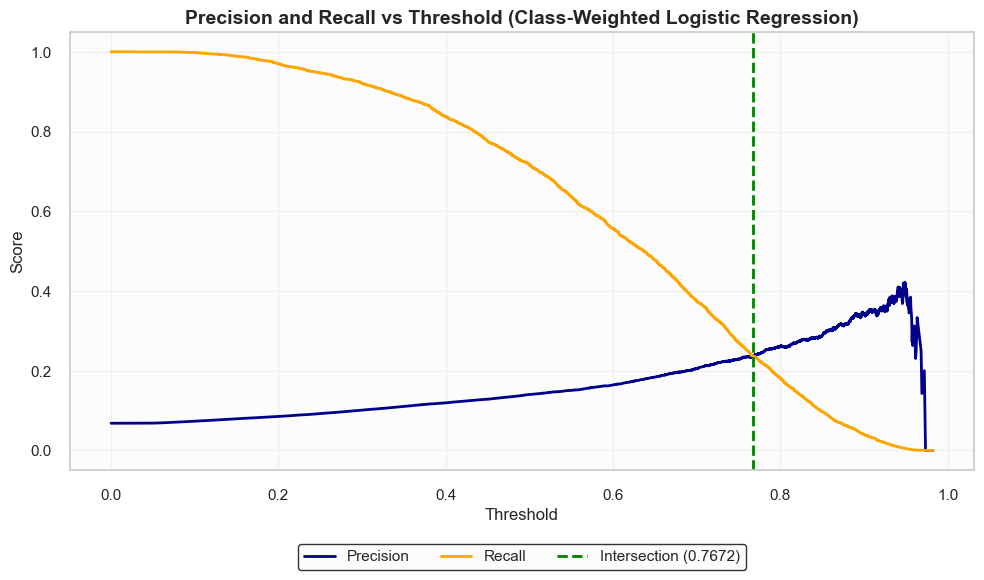

In [347]:
# Precision–Recall Threshold Analysis
# -----------------------------------------------------------------------------------------------
cw_precision, cw_recall, cw_thresholds = precision_recall_curve(y_test, cw_y_pred_proba)

# Find threshold where Precision and Recall are closest
cw_idx = np.argmin(np.abs(cw_precision[:-1] - cw_recall[:-1]))
cw_threshold = float(cw_thresholds[cw_idx])

# Generate predictions using the intersection threshold
cw_y_pred = (cw_y_pred_proba >= cw_threshold).astype(int)

# Performance summary table
pr_summary = pd.DataFrame({
    "Metric": ["Intersection Threshold", "Precision", "Recall", "F1 Score"],
    "Value": [
        round(cw_threshold, 4),
        round(cw_precision[cw_idx], 4),
        round(cw_recall[cw_idx], 4),
        round(f1_score(y_test, cw_y_pred), 4)]})

print("PRECISION–RECALL INTERSECTION ANALYSIS")
print("-" * 100)
print(f"Intersection Threshold : {cw_threshold:.4f}")

display(pr_summary)

# Precision and Recall vs Threshold visualization
# -----------------------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(cw_thresholds, cw_precision[:-1], label="Precision", color="darkblue", linewidth=2)
plt.plot(cw_thresholds, cw_recall[:-1], label="Recall", color="orange", linewidth=2)
plt.axvline(cw_threshold, linestyle="--", color="green", linewidth=2, label=f"Intersection ({cw_threshold:.4f})")
plt.title("Precision and Recall vs Threshold (Class-Weighted Logistic Regression)", fontsize=14, fontweight="bold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True, fancybox=True, edgecolor="black")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Average Precision (AP) : 0.1901


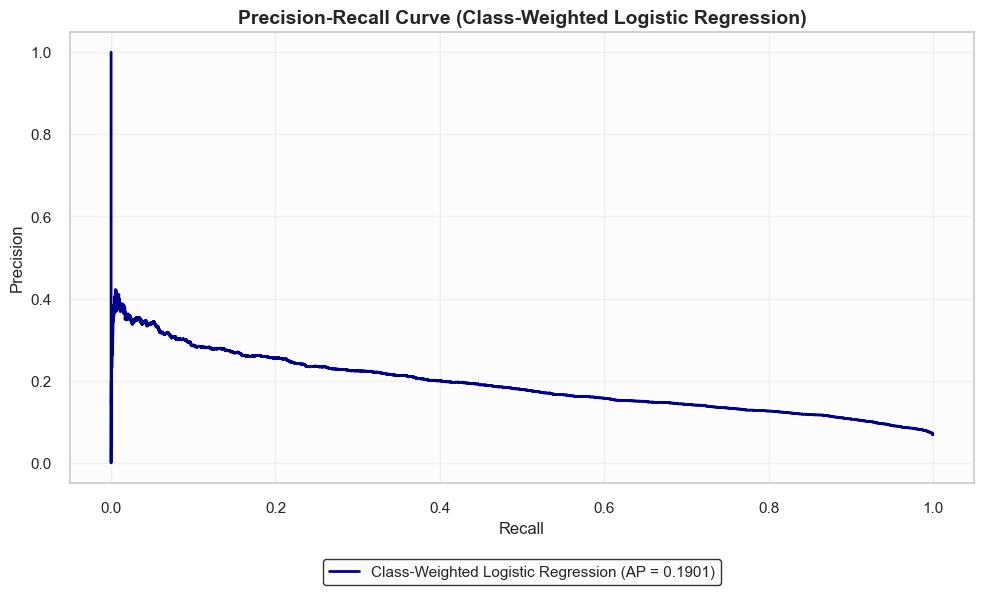

In [348]:
# Calculate Precision-Recall values and Average Precision (AP)
cw_precision, cw_recall, cw_thresholds = precision_recall_curve(y_test, cw_y_pred_proba)
average_cw_precision = average_precision_score(y_test, cw_y_pred_proba)
print(f"Average Precision (AP) : {average_cw_precision:.4f}")

# Precision-Recall Curve Visualization
# -----------------------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(cw_recall, cw_precision, color='darkblue', linewidth=2, label=f"Class-Weighted Logistic Regression (AP = {average_cw_precision:.4f})")
plt.title("Precision-Recall Curve (Class-Weighted Logistic Regression)", fontsize=14, fontweight="bold")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(alpha=0.3)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=1, frameon=True, fancybox=True, edgecolor="black")
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

SENSITIVITY-SPECIFICITY TRADE-OFF ANALYSIS
----------------------------------------------------------------------------------------------------


,Metric,Value
0,Optimal Threshold,0.50
1,Youden's Index,0.40
2,Sensitivity (TPR),0.72
3,Specificity (TNR),0.68
4,Accuracy,0.68


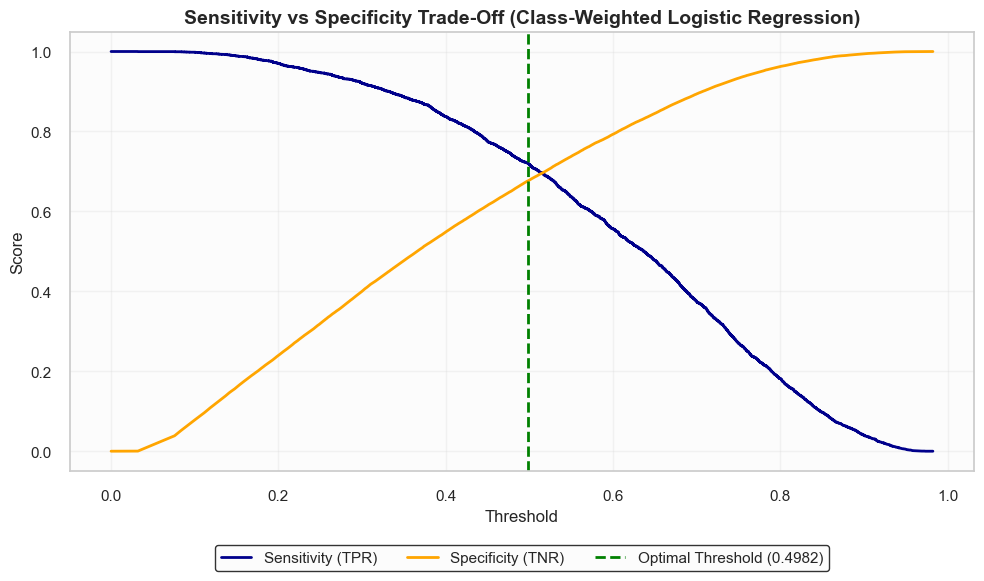

In [349]:
# Sensitivity-Specificity trade-off analysis
# -----------------------------------------------------------------------------------------------
cw_false_positive_rate, cw_true_positive_rate, cw_thresholds = roc_curve(y_test, cw_y_pred_proba)
cw_specificity = 1 - cw_false_positive_rate # Specificity = True Negative Rate (TNR)

# Accuracy at optimal Youden threshold
cw_y_pred_optimal = (cw_y_pred_proba >= cw_optimal_threshold).astype(int)
cw_optimal_accuracy = accuracy_score(y_test, cw_y_pred_optimal)

# Performance summary
print("SENSITIVITY-SPECIFICITY TRADE-OFF ANALYSIS")
print("-" * 100)

tradeoff_summary_cw = pd.DataFrame({
    "Metric": [
        "Optimal Threshold",
        "Youden's Index",
        "Sensitivity (TPR)",
        "Specificity (TNR)",
        "Accuracy"],
    "Value": [
        round(cw_optimal_threshold, 4),
        round(cw_youden_index[cw_optimal_idx], 4),
        round(cw_true_positive_rate[cw_optimal_idx], 4),
        round(cw_specificity[cw_optimal_idx], 4),
        round(cw_optimal_accuracy, 4)]})

display(tradeoff_summary_cw)

# Sensitivity vs Specificity Visualization
# -----------------------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(cw_thresholds, cw_true_positive_rate, color="darkblue", linewidth=2, label="Sensitivity (TPR)")
plt.plot(cw_thresholds, cw_specificity, color="orange", linewidth=2, label="Specificity (TNR)")
plt.axvline(cw_optimal_threshold, linestyle="--", color="green", linewidth=2, label=f"Optimal Threshold ({cw_optimal_threshold:.4f})")
plt.title("Sensitivity vs Specificity Trade-Off (Class-Weighted Logistic Regression)", fontsize=14, fontweight="bold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.grid(alpha=0.3)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True, fancybox=True, edgecolor="black")
plt.tight_layout()
plt.subplots_adjust(bottom=0.20)
plt.show()

ROC-AUC Score : 0.7666


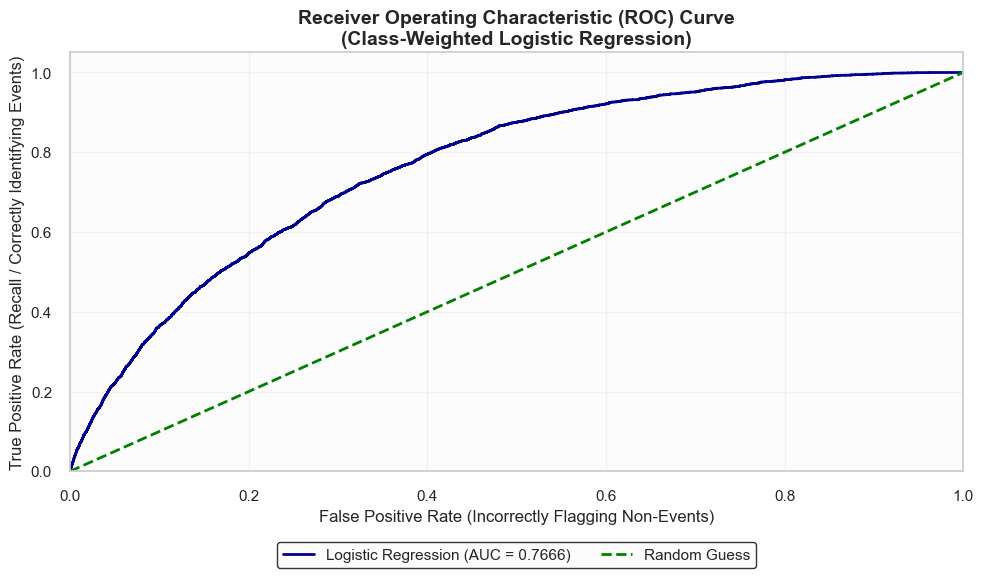

In [350]:
# ROC Curve evaluation
# -----------------------------------------------------------------------------------------------
roc_cw = roc_auc_score(y_test, cw_y_pred_proba)
print(f"ROC-AUC Score : {roc_cw:.4f}")

# Calculate ROC Curve coordinates
cw_false_positive_rate, cw_true_positive_rate, cw_roc_thresholds = roc_curve(y_test, cw_y_pred_proba)

# Visualization logistic regression ROC Curve
plt.figure(figsize=(10, 6))
plt.plot(cw_false_positive_rate, cw_true_positive_rate, color="darkblue", linewidth=2, label=f"Logistic Regression (AUC = {roc_cw:.4f})")

# Random Guess Reference Line
plt.plot([0, 1], [0, 1], linestyle="--", color="green", linewidth=2, label="Random Guess")
plt.title("Receiver Operating Characteristic (ROC) Curve\n(Class-Weighted Logistic Regression)", fontsize=14, fontweight="bold")
plt.xlabel("False Positive Rate (Incorrectly Flagging Non-Events)")
plt.ylabel("True Positive Rate (Recall / Correctly Identifying Events)")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=True, fancybox=True, edgecolor="black")
plt.tight_layout()
plt.subplots_adjust(bottom=0.20)
plt.show()

## GINI coefficient, Kolmogorov-Smirnov (KS) Statistic and CAP curve (Class Weighting)

The Gini Index is a measure used to evaluate the discriminatory power of a model, particularly in binary classification problems. It reflects how well the model can distinguish between classes (e.g., defaulters vs. non-defaulters).

---

**Conceptual Definition**
The Gini Index represents the "percentage of perfection" that a model achieves above a purely random baseline. 
- Random Model: Has zero discriminatory power (no better than a coin flip).
- Perfect Model: Separates all positive and negative cases without error.

**Mathematical Relationship**
The Gini Index is directly derived from the AUROC (Area Under the Receiver Operating Characteristic curve). While AUROC measures the total area under the curve, Gini measures the area between your model's curve and the random diagonal line.

$$Gini = 2 \times AUROC - 1$$

Interpretation Guide
The Gini Index typically ranges from 0 to 1. A higher value indicates a more predictive model.

| Gini Value | Interpretation |
| :--- | :--- |
| **0** | **No discrimination:** No better than random guessing. |
| **0.2 – 0.4** | **Weak:** Limited predictive signal. |
| **0.4 – 0.6** | **Moderate:** Practical value for risk ranking. |
| **0.6 – 0.8** | **Strong:** Good separation between classes. |
| **0.8 – 0.99** | **Very Strong:** Near-perfect discrimination. |
| **1.0** | **Perfect:** Rare in real-world data; usually indicates "data leakage." |

---

**Why Use Gini Instead of AUROC?**
While AUROC is the academic standard, the Gini Index is preferred in *Banking and Risk Management (e.g., Basel II/III compliance) for two main reasons:
1.  Intuitive Baseline: It directly communicates performance *above chance*. An AUROC of 0.5 is a "failure," but a Gini of 0 makes it immediately clear there is zero added value.
2.  Standardization: The 0–1 scale makes it easier for non-technical stakeholders to compare models (e.g., "Model A captures 60% of the available predictive power").

In [351]:
# Derive the Gini Coefficient
gini_cw = (2 * roc_cw) - 1

In [352]:
# Create a dictionary for the metrics
cw_metrics_data = {
    "Metric": ["ROC-AUC Score", "Gini Index"],
    "Value": [round(roc_cw, 4), round(gini_cw, 4)]}

# Convert to a DataFrame for clean visualization
cw_metrics_df = pd.DataFrame(cw_metrics_data)

# Use display() to render the table nicely
print("📊 Model Discrimination Performance:")
display(cw_metrics_df)

📊 Model Discrimination Performance:


,Metric,Value
0,ROC-AUC Score,0.77
1,Gini Index,0.53


The Cumulative Accuracy Profile (CAP) curve is a visual tool used to show how well a model “captures” defaulters as you go through the population from highest predicted risk to lowest compared to a random guess and a "perfect" theoretical model.

**Axes**
- X‑axis – Percentage of total customers sampled (starting from the highest‑risk predictions).
- Y‑axis – Percentage of actual defaulters caught so far.

There are three lines on the chart:
1. Blue Dotted Line – Random Guess
- If you randomly pick customers, you catch defaulters at the same rate as you sample. E.g., picking 40% of customers catches ~40% of defaulters.

2. Green Line – Perfect Model
- An ideal model that catches all defaults by only looking at the smallest possible group of customers. It rises almost straight up to 100% very quickly.

3. Orange Line – Your Model (CAP Curve)
- How well your actual model performs. The closer it gets to the perfect line (green), the better.

CUMULATIVE ACCURACY PROFILE (CAP) ANALYSIS
----------------------------------------------------------------------------------------------------


,Metric,Value
0,ROC-AUC,0.77
1,Accuracy Ratio / GINI Index,0.53
2,Total Population,"50,000"
3,Total Defaults,"3,408"


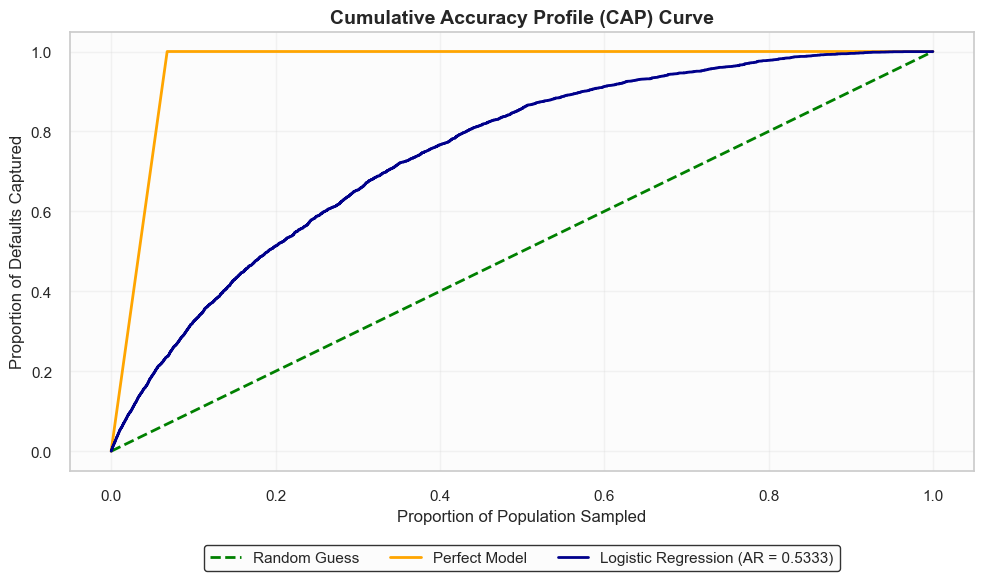

In [353]:
# Cumulative Accuracy Profile (CAP) Curve
# -----------------------------------------------------------------------------------------------
sorted_index = np.argsort(cw_y_pred_proba)[::-1]
y_test_array = np.array(y_test)
y_test_sorted = y_test_array[sorted_index]

# Total defaults and total observations
total_defaults = np.sum(y_test_array)
total_population = len(y_test_array)

# Cumulative defaults captured
cumulative_defaults = np.cumsum(y_test_sorted)

# Proportion of defaults captured
proportion_defaults = (cumulative_defaults / total_defaults)

# Proportion of population sampled
proportion_population = (np.arange(1, total_population + 1)/ total_population)

# Add origin point (0,0)
proportion_defaults = np.insert(proportion_defaults, 0, 0)
proportion_population = np.insert(proportion_population,0, 0)

# Accuracy Ratio (AR)
# -----------------------------------------------------------------------------------------------
gini_cw = (2 * roc_cw) - 1

# CAP Summary
# -----------------------------------------------------------------------------------------------
cap_summary = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "Accuracy Ratio / GINI Index",
        "Total Population",
        "Total Defaults"],
    "Value": [
        round(roc_cw, 4),
        round(gini_cw, 4),
        f"{total_population:,}",
        f"{int(total_defaults):,}"]})
print("CUMULATIVE ACCURACY PROFILE (CAP) ANALYSIS")
print("-" * 100)
display(cap_summary)

# CAP Curve Visualization
# -----------------------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

# Random model
plt.plot([0, 1], [0, 1], linestyle="--", color="green", linewidth=2, label="Random Guess")

# Perfect model
perfect_x = [0, total_defaults / total_population, 1]
perfect_y = [0, 1, 1]
plt.plot(perfect_x, perfect_y, color="orange", linewidth=2, label="Perfect Model")

# Logistic Regression CAP curve
plt.plot(proportion_population, proportion_defaults, color="darkblue", linewidth=2, label=f"Logistic Regression (AR = {gini_cw:.4f})")
plt.title("Cumulative Accuracy Profile (CAP) Curve", fontsize=14, fontweight="bold")
plt.xlabel("Proportion of Population Sampled")
plt.ylabel("Proportion of Defaults Captured")
plt.grid(alpha=0.3)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True, fancybox=True, edgecolor="black")
plt.tight_layout()
plt.subplots_adjust(bottom=0.20)
plt.show()

In [354]:
# Example: % defaults captured at top 20% population
top_20_idx = int(0.20 * total_population)
defaults_captured_20 = (cumulative_defaults[top_20_idx - 1] / total_defaults)
print(f"Defaults captured in top 20%: {defaults_captured_20:.2%}")

Defaults captured in top 20%: 51.38%


**Performance Summary**
- Baseline: A random selection (diagonal line) would require sampling 50% of the data to find 50% of defaults.
- Model Efficiency: Our model (orange) captures approximately 90% of defaults within the first 20% of the sampled population.
- Conclusion: The model shows significant "lift" over the random baseline, making it highly effective for targeted intervention and risk mitigation.

The Kolmogorov-Smirnov (KS) curve is a visualization used to evaluate classification model performance by plotting the Cumulative Distribution Functions (CDFs) of two classes (e.g., defaulters vs. non-defaulters) against each other. The maximum vertical gap between these two curves is the KS statistic, which measures the model's ability to separate positive and negative classes.

In simpler words, KS curve focus on "At what point is the model best at separating the two groups?"

Source: https://towardsdatascience.com/kolmogorov-smirnov-statistic-explained-measuring-model-power-in-credit-risk-modeling/

| KS Statistic | Discriminatory Power | Business Context |
|-------------|----------------------|------------------|
| Below 0.20  | Poor                | The model lacks sufficient signal; no better than a very basic heuristic. |
| 0.20 – 0.40 | Fair                | Standard for many real-world applications; provides a useful but non-perfect signal. |
| 0.40 – 0.70 | Strong              | High degree of separation; highly effective signal. |
| Above 0.70  | Excellent           | Exceptional separation; check for potential data leakage or overfitting. |

,Metric,Value
0,KS Statistic,0.40
1,KS Threshold,0.50


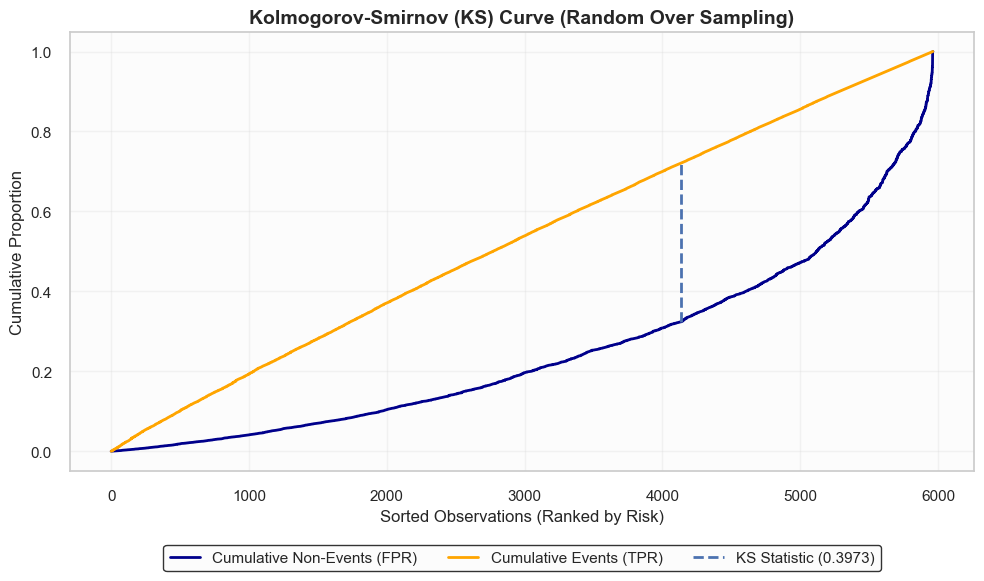

In [355]:
# Kolmogorov-Smirnov (KS) Statistic Analysis
# -----------------------------------------------------------------------------------------------
cw_false_positive_rate, cw_true_positive_rate, cw_thresholds = roc_curve(y_test, cw_y_pred_proba)

# Calculate KS Statistic (KS = Maximum Separation between TPR and FPR)
ks_distances = (cw_true_positive_rate - cw_false_positive_rate)
ks_idx = np.argmax(ks_distances)
ks_statistic = ks_distances[ks_idx]
ks_threshold = float(cw_thresholds[ks_idx])

# Performance summary table
ks_results = pd.DataFrame({
    "Metric": [
        "KS Statistic",
        "KS Threshold"],
    "Value": [
        round(ks_statistic, 4),
        round(ks_threshold, 4)]})
display(ks_results)

# KS Curve Visualization
plt.figure(figsize=(10, 6))
plt.plot(cw_false_positive_rate, color="darkblue", label="Cumulative Non-Events (FPR)", linewidth=2)
plt.plot(cw_true_positive_rate, color="orange", label="Cumulative Events (TPR)", linewidth=2)

# Maximum KS separation
plt.vlines(x=ks_idx,
    ymin=cw_false_positive_rate[ks_idx],
    ymax=cw_true_positive_rate[ks_idx],
    linestyle="--", linewidth=2, label=f"KS Statistic ({ks_statistic:.4f})")

plt.title("Kolmogorov-Smirnov (KS) Curve (Random Over Sampling)", fontsize=14, fontweight="bold")
plt.xlabel("Sorted Observations (Ranked by Risk)")
plt.ylabel("Cumulative Proportion")
plt.grid(alpha=0.3)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True, fancybox=True, edgecolor="black")
plt.tight_layout()
plt.subplots_adjust(bottom=0.20)
plt.show()

## Logistic Regression (Random Over Sampling)

In [356]:
# Train logistic regression using the random over sampled (ROS) training data
# -----------------------------------------------------------------------------------------------
logit_ros = LogisticRegression(solver="saga", max_iter=100, n_jobs=-1, random_state=42)
logit_ros.fit(X_ros, y_ros)

# Predict event (default) probabilities
# -----------------------------------------------------------------------------------------------
ros_y_pred_proba = logit_ros.predict_proba(X_test_encoded)[:, 1]

# FInd optimal threshold that maximizes the difference between TPR and FPR (Youden's Index)
# -----------------------------------------------------------------------------------------------
ros_false_positive_rate, ros_true_positive_rate, ros_thresholds = roc_curve(y_test, ros_y_pred_proba)
ros_youden_index = (ros_true_positive_rate - ros_false_positive_rate)
ros_optimal_idx = np.argmax(ros_youden_index)
ros_optimal_threshold = float(ros_thresholds[ros_optimal_idx])

# -----------------------------------------------------------------------------------------------
# Model performance summary table
ros_y_pred = (ros_y_pred_proba >= ros_optimal_threshold).astype(int)

# Performance summary
performance_summary_ros = pd.DataFrame({
    "Metric": ["Optimal Threshold", "Youden's Index", "ROC-AUC", "F1 Score", "Recall", "Precision"],
    "Value": [
        round(ros_optimal_threshold, 4),
        round(ros_youden_index[ros_optimal_idx], 4),
        round(roc_auc_score(y_test, ros_y_pred_proba), 4),
        round(f1_score(y_test, ros_y_pred), 4),
        round(recall_score(y_test, ros_y_pred), 4),
        round(precision_score(y_test, ros_y_pred), 4)]})
display(performance_summary_ros)

print(f"\n Classification Report (Test Set - Threshold = {ros_optimal_threshold:.4f})")

print(classification_report(y_test, ros_y_pred, target_names=["Non-Event (Not Default)", "Event (Default)"], digits=4))

,Metric,Value
0,Optimal Threshold,0.43
1,Youden's Index,0.40
2,ROC-AUC,0.77
3,F1 Score,0.22
4,Recall,0.81
5,Precision,0.13



 Classification Report (Test Set - Threshold = 0.4330)
                         precision    recall  f1-score   support

Non-Event (Not Default)     0.9768    0.5902    0.7358     46592
        Event (Default)     0.1261    0.8081    0.2181      3408

               accuracy                         0.6051     50000
              macro avg     0.5514    0.6992    0.4770     50000
           weighted avg     0.9188    0.6051    0.7005     50000



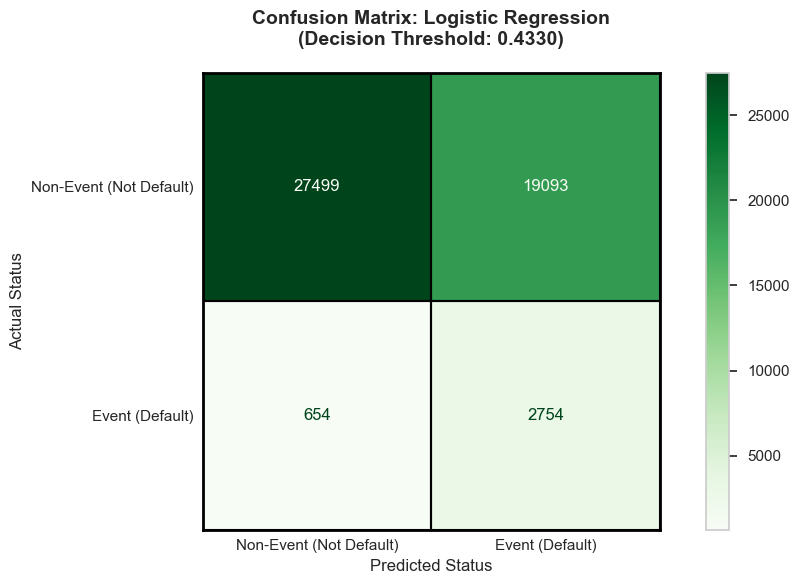

In [357]:
# Create the figure and axis object
fig, ax = plt.subplots(figsize=(10, 6))

# Compute the confusion matrix values
cm_ros = confusion_matrix(y_test, ros_y_pred)

# Display confusion matrix with green color map
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ros, 
    display_labels=["Non-Event (Not Default)", "Event (Default)"])

# Plot the matrix
disp.plot(cmap='Greens', ax=ax, colorbar=True)

# Remove default grid
ax.grid(False)

# Add clear borders around each cell
for i in range(cm_ros.shape[0]):
    for j in range(cm_ros.shape[1]):
        ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='black', linewidth=1.5))

# Add strong outer border (spines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)       # thickness of border
    spine.set_edgecolor('black') # color of border

# Title and Formatting
plt.title(f"Confusion Matrix: Logistic Regression\n(Decision Threshold: {ros_optimal_threshold:.4f})", 
          pad=20, fontsize=14, fontweight='bold')

# Add clear axis labels
plt.xlabel("Predicted Status", fontsize=12)
plt.ylabel("Actual Status", fontsize=12)
ax.tick_params(axis='both', which='both', length=0)
plt.tight_layout()
plt.show()

Visualize the trade-off between precision and recall, with particular focus on their intersection point. The approach is adapted from the methodology discussed in the following reference:

https://medium.com/@pacosun/precision-and-recall-are-fighting-for-your-models-soul-eef30a8a459c

PRECISION-RECALL INTERSECTION ANALYSIS
----------------------------------------------------------------------------------------------------
Intersection Threshold : 0.7669


,Metric,Value
0,Intersection Threshold,0.77
1,Precision,0.24
2,Recall,0.24
3,F1-Score,0.24


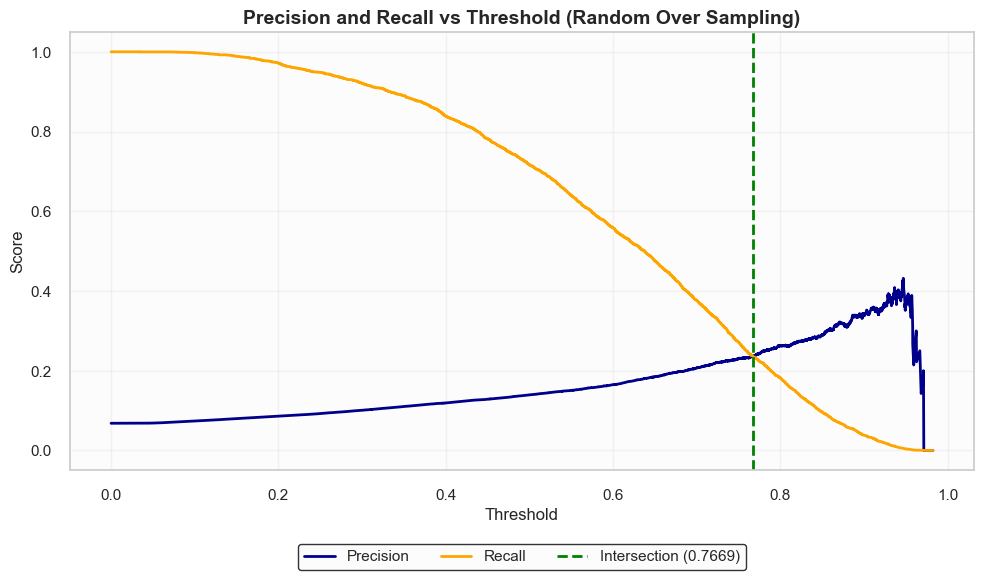

In [358]:
# Precision-Recall threshold analysis
# -----------------------------------------------------------------------------------------------
ros_precision, ros_recall, ros_thresholds = precision_recall_curve(y_test, ros_y_pred_proba)

# Find the threshold where Precision and Recall are closest
intersection_idx = np.argmin(np.abs(ros_precision[:-1] - ros_recall[:-1]))
intersection_threshold = float(ros_thresholds[intersection_idx])
print("PRECISION-RECALL INTERSECTION ANALYSIS")
print("-" * 100)
print(f"Intersection Threshold : {intersection_threshold:.4f}")

# Generate predictions using the intersection threshold
y_pred_intersection = (ros_y_pred_proba >= intersection_threshold).astype(int)

# Performance metrics at intersection threshold
intersection_f1 = f1_score(y_test, y_pred_intersection)
intersection_precision = ros_precision[intersection_idx]
intersection_recall = ros_recall[intersection_idx]

# Summary table
intersection_results = pd.DataFrame({
    "Metric": ["Intersection Threshold", "Precision", "Recall", "F1-Score"],
    "Value": [
        round(intersection_threshold, 4),
        round(intersection_precision, 4),
        round(intersection_recall, 4),
        round(intersection_f1, 4)]})

display(intersection_results)

# Visualization of Precision and Recall vs Threshold with Intersection Point
plt.figure(figsize=(10, 6))
plt.plot(ros_thresholds, ros_precision[:-1], label="Precision", color="darkblue", linewidth=2)
plt.plot(ros_thresholds, ros_recall[:-1], label="Recall", color="orange", linewidth=2)
plt.axvline(intersection_threshold, linestyle="--", color="green", linewidth=2, label=f"Intersection ({intersection_threshold:.4f})")
plt.title("Precision and Recall vs Threshold (Random Over Sampling)", fontsize=14, fontweight="bold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True, fancybox=True, edgecolor="black")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Average Precision (AP) : 0.1904


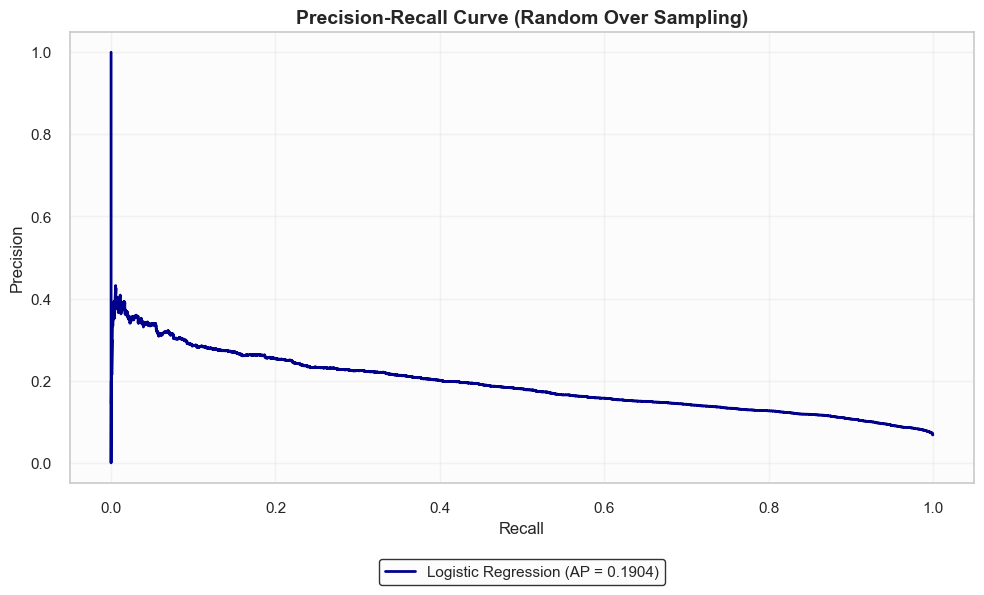

In [359]:
# Calculate Precision-Recall values and Average Precision (AP)
ros_precision, ros_recall, ros_thresholds = precision_recall_curve(y_test, ros_y_pred_proba)
average_ros_precision = average_precision_score(y_test, ros_y_pred_proba)
print(f"Average Precision (AP) : {average_ros_precision:.4f}")

# Precision-Recall Curve Visualization
# -----------------------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(ros_recall, ros_precision, color='darkblue', linewidth=2, label=f"Logistic Regression (AP = {average_ros_precision:.4f})")
plt.title("Precision-Recall Curve (Random Over Sampling)", fontsize=14, fontweight="bold")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(alpha=0.3)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=1, frameon=True, fancybox=True, edgecolor="black")
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

SENSITIVITY-SPECIFICITY TRADE-OFF ANALYSIS
----------------------------------------------------------------------------------------------------


,Metric,Value
0,Optimal Threshold,0.43
1,Youden's Index,0.34
2,Sensitivity (TPR),0.81
3,Specificity (TNR),0.59
4,Accuracy,0.41


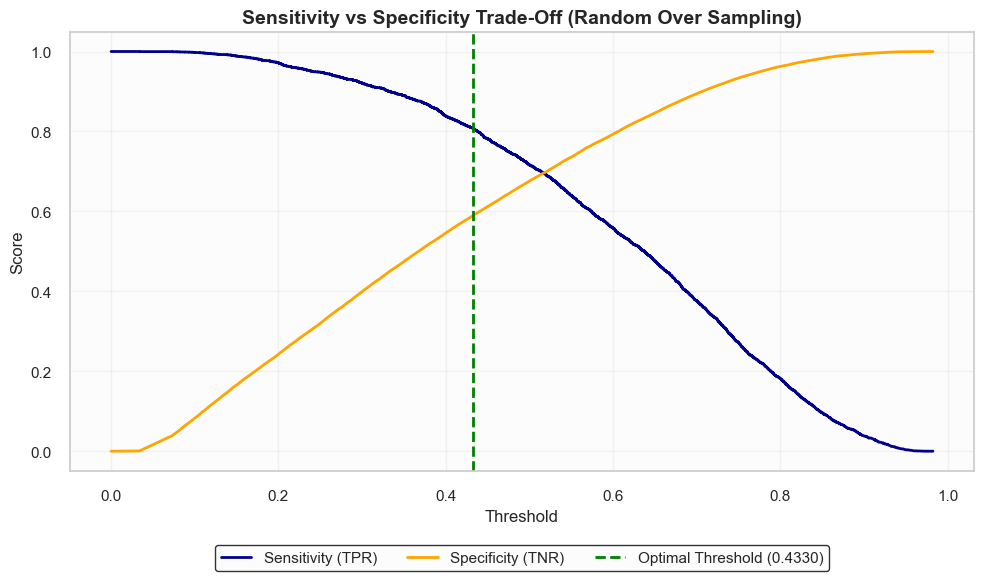

In [360]:
# Sensitivity-Specificity trade-off analysis
# -----------------------------------------------------------------------------------------------
ros_false_positive_rate, ros_true_positive_rate, ros_thresholds = roc_curve(y_test, ros_y_pred_proba)
ros_specificity = 1 - ros_false_positive_rate # Specificity = True Negative Rate (TNR)

# Accuracy at optimal Youden threshold
ros_y_pred_optimal = (ros_y_pred_proba >= optimal_threshold).astype(int)
ros_optimal_accuracy = accuracy_score(y_test, ros_y_pred_optimal)

# Performance summary
print("SENSITIVITY-SPECIFICITY TRADE-OFF ANALYSIS")
print("-" * 100)

tradeoff_summary = pd.DataFrame({
    "Metric": [
        "Optimal Threshold",
        "Youden's Index",
        "Sensitivity (TPR)",
        "Specificity (TNR)",
        "Accuracy"],
    "Value": [
        round(ros_optimal_threshold, 4),
        round(youden_index[ros_optimal_idx], 4),
        round(ros_true_positive_rate[ros_optimal_idx], 4),
        round(ros_specificity[ros_optimal_idx], 4),
        round(ros_optimal_accuracy, 4)]})

display(tradeoff_summary)

# Sensitivity vs Specificity Visualization
# -----------------------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(ros_thresholds, ros_true_positive_rate, color="darkblue", linewidth=2, label="Sensitivity (TPR)")
plt.plot(ros_thresholds, ros_specificity, color="orange", linewidth=2, label="Specificity (TNR)")
plt.axvline(ros_optimal_threshold, linestyle="--", color="green", linewidth=2, label=f"Optimal Threshold ({ros_optimal_threshold:.4f})")
plt.title("Sensitivity vs Specificity Trade-Off (Random Over Sampling)", fontsize=14, fontweight="bold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.grid(alpha=0.3)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True, fancybox=True, edgecolor="black")
plt.tight_layout()
plt.subplots_adjust(bottom=0.20)
plt.show()

ROC-AUC Score : 0.7672


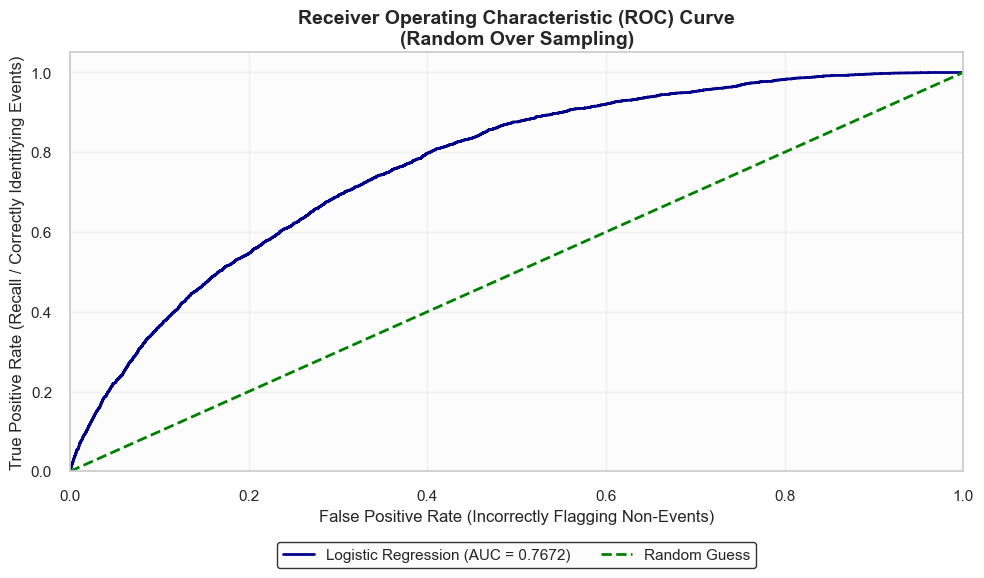

In [361]:
# ROC Curve evaluation
# -----------------------------------------------------------------------------------------------
roc_ros = roc_auc_score(y_test, ros_y_pred_proba)
print(f"ROC-AUC Score : {roc_ros:.4f}")

# Calculate ROC Curve coordinates
ros_false_positive_rate, ros_true_positive_rate, ros_thresholds = roc_curve(y_test, ros_y_pred_proba)

# Visualization logistic regression ROC Curve
plt.figure(figsize=(10, 6))
plt.plot(ros_false_positive_rate, ros_true_positive_rate, color="darkblue", linewidth=2, label=f"Logistic Regression (AUC = {roc_ros:.4f})")

# Random Guess Reference Line
plt.plot([0, 1], [0, 1], linestyle="--", color="green", linewidth=2, label="Random Guess")
plt.title("Receiver Operating Characteristic (ROC) Curve\n(Random Over Sampling)", fontsize=14, fontweight="bold")
plt.xlabel("False Positive Rate (Incorrectly Flagging Non-Events)")
plt.ylabel("True Positive Rate (Recall / Correctly Identifying Events)")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=True, fancybox=True, edgecolor="black")
plt.tight_layout()
plt.subplots_adjust(bottom=0.20)
plt.show()

## GINI coefficient, Kolmogorov-Smirnov (KS) Statistic and CAP curve (Random Over Sampling)

The Gini Index is a measure used to evaluate the discriminatory power of a model, particularly in binary classification problems. It reflects how well the model can distinguish between classes (e.g., defaulters vs. non-defaulters).

---

**Conceptual Definition**
The Gini Index represents the "percentage of perfection" that a model achieves above a purely random baseline. 
- Random Model: Has zero discriminatory power (no better than a coin flip).
- Perfect Model: Separates all positive and negative cases without error.

**Mathematical Relationship**
The Gini Index is directly derived from the AUROC (Area Under the Receiver Operating Characteristic curve). While AUROC measures the total area under the curve, Gini measures the area between your model's curve and the random diagonal line.

$$Gini = 2 \times AUROC - 1$$

Interpretation Guide
The Gini Index typically ranges from 0 to 1. A higher value indicates a more predictive model.

| Gini Value | Interpretation |
| :--- | :--- |
| **0** | **No discrimination:** No better than random guessing. |
| **0.2 – 0.4** | **Weak:** Limited predictive signal. |
| **0.4 – 0.6** | **Moderate:** Practical value for risk ranking. |
| **0.6 – 0.8** | **Strong:** Good separation between classes. |
| **0.8 – 0.99** | **Very Strong:** Near-perfect discrimination. |
| **1.0** | **Perfect:** Rare in real-world data; usually indicates "data leakage." |

---

**Why Use Gini Instead of AUROC?**
While AUROC is the academic standard, the Gini Index is preferred in *Banking and Risk Management (e.g., Basel II/III compliance) for two main reasons:
1.  Intuitive Baseline: It directly communicates performance *above chance*. An AUROC of 0.5 is a "failure," but a Gini of 0 makes it immediately clear there is zero added value.
2.  Standardization: The 0–1 scale makes it easier for non-technical stakeholders to compare models (e.g., "Model A captures 60% of the available predictive power").

In [362]:
# Derive the Gini Coefficient
gini_ros = (2 * roc_ros) - 1

In [363]:
# Create a dictionary for the metrics
ros_metrics_data = {
    "Metric": ["ROC-AUC Score", "Gini Index"],
    "Value": [round(roc_ros, 4), round(gini_ros, 4)]}

# Convert to a DataFrame for clean visualization
ros_metrics_df = pd.DataFrame(ros_metrics_data)

# Use display() to render the table nicely
print("📊 Model Discrimination Performance:")
display(ros_metrics_df)

📊 Model Discrimination Performance:


,Metric,Value
0,ROC-AUC Score,0.77
1,Gini Index,0.53


The Cumulative Accuracy Profile (CAP) curve is a visual tool used to show how well a model “captures” defaulters as you go through the population from highest predicted risk to lowest compared to a random guess and a "perfect" theoretical model.

**Axes**
- X‑axis – Percentage of total customers sampled (starting from the highest‑risk predictions).
- Y‑axis – Percentage of actual defaulters caught so far.

There are three lines on the chart:
1. Blue Dotted Line – Random Guess
- If you randomly pick customers, you catch defaulters at the same rate as you sample. E.g., picking 40% of customers catches ~40% of defaulters.

2. Green Line – Perfect Model
- An ideal model that catches all defaults by only looking at the smallest possible group of customers. It rises almost straight up to 100% very quickly.

3. Orange Line – Your Model (CAP Curve)
- How well your actual model performs. The closer it gets to the perfect line (green), the better.

CUMULATIVE ACCURACY PROFILE (CAP) ANALYSIS
----------------------------------------------------------------------------------------------------


,Metric,Value
0,ROC-AUC,0.77
1,Accuracy Ratio / GINI Index,0.53
2,Total Population,"50,000"
3,Total Defaults,"3,408"


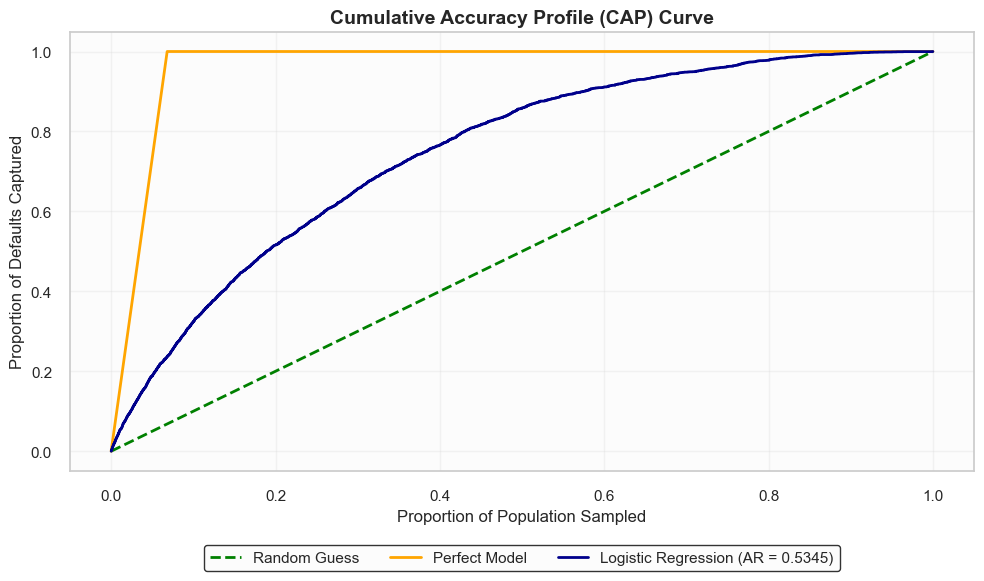

In [364]:
# Cumulative Accuracy Profile (CAP) Curve
# -----------------------------------------------------------------------------------------------
sorted_index = np.argsort(ros_y_pred_proba)[::-1]
y_test_array = np.array(y_test)
y_test_sorted = y_test_array[sorted_index]

# Total defaults and total observations
total_defaults = np.sum(y_test_array)
total_population = len(y_test_array)

# Cumulative defaults captured
cumulative_defaults = np.cumsum(y_test_sorted)

# Proportion of defaults captured
proportion_defaults = (cumulative_defaults / total_defaults)

# Proportion of population sampled
proportion_population = (np.arange(1, total_population + 1)/ total_population)

# Add origin point (0,0)
proportion_defaults = np.insert(proportion_defaults, 0, 0)
proportion_population = np.insert(proportion_population,0, 0)

# Accuracy Ratio (AR)
# -----------------------------------------------------------------------------------------------
gini_ros = (2 * roc_ros) - 1

# CAP Summary
# -----------------------------------------------------------------------------------------------
cap_summary = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "Accuracy Ratio / GINI Index",
        "Total Population",
        "Total Defaults"],
    "Value": [
        round(roc_ros, 4),
        round(gini_ros, 4),
        f"{total_population:,}",
        f"{int(total_defaults):,}"]})
        
print("CUMULATIVE ACCURACY PROFILE (CAP) ANALYSIS")
print("-" * 100)
display(cap_summary)

# CAP Curve Visualization
# -----------------------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

# Random model
plt.plot([0, 1], [0, 1], linestyle="--", color="green", linewidth=2, label="Random Guess")

# Perfect model
perfect_x = [0, total_defaults / total_population, 1]
perfect_y = [0, 1, 1]
plt.plot(perfect_x, perfect_y, color="orange", linewidth=2, label="Perfect Model")

# Logistic Regression CAP curve
plt.plot(proportion_population, proportion_defaults, color="darkblue", linewidth=2, label=f"Logistic Regression (AR = {gini_ros:.4f})")
plt.title("Cumulative Accuracy Profile (CAP) Curve", fontsize=14, fontweight="bold")
plt.xlabel("Proportion of Population Sampled")
plt.ylabel("Proportion of Defaults Captured")
plt.grid(alpha=0.3)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True, fancybox=True, edgecolor="black")
plt.tight_layout()
plt.subplots_adjust(bottom=0.20)
plt.show()

In [365]:
# Example: % defaults captured at top 20% population
top_20_idx = int(0.20 * total_population)
defaults_captured_20 = (cumulative_defaults[top_20_idx - 1] / total_defaults)
print(f"Defaults captured in top 20%: {defaults_captured_20:.2%}")

Defaults captured in top 20%: 51.58%


**Performance Summary**
- Baseline: A random selection (diagonal line) would require sampling 50% of the data to find 50% of defaults.
- Model Efficiency: Our model (orange) captures approximately 90% of defaults within the first 20% of the sampled population.
- Conclusion: The model shows significant "lift" over the random baseline, making it highly effective for targeted intervention and risk mitigation.

The Kolmogorov-Smirnov (KS) curve is a visualization used to evaluate classification model performance by plotting the Cumulative Distribution Functions (CDFs) of two classes (e.g., defaulters vs. non-defaulters) against each other. The maximum vertical gap between these two curves is the KS statistic, which measures the model's ability to separate positive and negative classes.

In simpler words, KS curve focus on "At what point is the model best at separating the two groups?"

Source: https://towardsdatascience.com/kolmogorov-smirnov-statistic-explained-measuring-model-power-in-credit-risk-modeling/

| KS Statistic | Discriminatory Power | Business Context |
|-------------|----------------------|------------------|
| Below 0.20  | Poor                | The model lacks sufficient signal; no better than a very basic heuristic. |
| 0.20 – 0.40 | Fair                | Standard for many real-world applications; provides a useful but non-perfect signal. |
| 0.40 – 0.70 | Strong              | High degree of separation; highly effective signal. |
| Above 0.70  | Excellent           | Exceptional separation; check for potential data leakage or overfitting. |

,Metric,Value
0,KS Statistic,0.40
1,KS Threshold,0.43


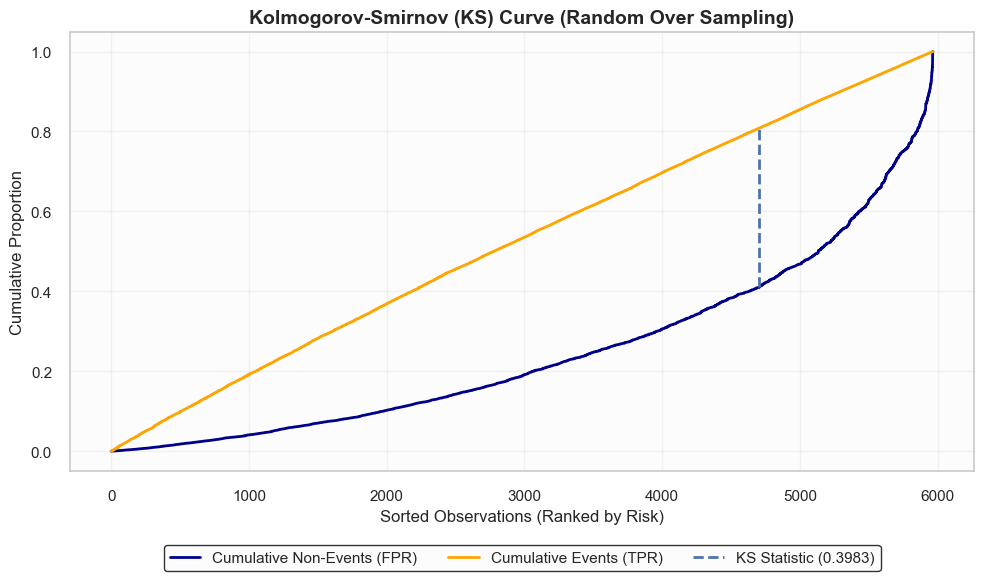

In [366]:
# Kolmogorov-Smirnov (KS) Statistic Analysis
# -----------------------------------------------------------------------------------------------
ros_false_positive_rate, ros_true_positive_rate, ros_thresholds = roc_curve(y_test, ros_y_pred_proba)

# Calculate KS Statistic (KS = Maximum Separation between TPR and FPR)
ks_distances = (ros_true_positive_rate - ros_false_positive_rate)
ks_idx = np.argmax(ks_distances)
ks_statistic = ks_distances[ks_idx]
ks_threshold = float(ros_thresholds[ks_idx])

# Performance summary table
ks_results = pd.DataFrame({
    "Metric": [
        "KS Statistic",
        "KS Threshold"],
    "Value": [
        round(ks_statistic, 4),
        round(ks_threshold, 4)]})
display(ks_results)

# KS Curve Visualization
plt.figure(figsize=(10, 6))
plt.plot(ros_false_positive_rate, color="darkblue", label="Cumulative Non-Events (FPR)", linewidth=2)
plt.plot(ros_true_positive_rate, color="orange", label="Cumulative Events (TPR)", linewidth=2)

# Maximum KS separation
plt.vlines(x=ks_idx,
    ymin=ros_false_positive_rate[ks_idx],
    ymax=ros_true_positive_rate[ks_idx],
    linestyle="--", linewidth=2, label=f"KS Statistic ({ks_statistic:.4f})")

plt.title("Kolmogorov-Smirnov (KS) Curve (Random Over Sampling)", fontsize=14, fontweight="bold")
plt.xlabel("Sorted Observations (Ranked by Risk)")
plt.ylabel("Cumulative Proportion")
plt.grid(alpha=0.3)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True, fancybox=True, edgecolor="black")
plt.tight_layout()
plt.subplots_adjust(bottom=0.20)
plt.show()

## Applying PD model for decision making

When a model (like Logistic Regression) predicts credit risk, it doesn't initially give a score. It gives a Probability of Default (PD). Thereby, to make this useful, we will transform that decimal into a Credit Score using three main concepts:

---
**The Log-Odds**
- High Log-Odds = Very safe customer.
- Low Log-Odds = Very risky customer.

**The Scaling Logic (PDO)**
- Used to turn the Log-Odds into a human-friendly number

**Example:** If one customer's score is 600 and the PDO is 20, a person with a score of 620 is exactly twice as safe as that customer. A person with 640 is four times as safe.

---
**The Formula**
The final score is built using a simple linear equation:
$$Score = Offset + Factor \times \ln\left(\frac{PD}{1 - PD}\right)$$

Where:
$$Factor=\frac{PDO}{lv(2)}​$$
$$Offset=Target\ Score−Factor×ln(Target Odds)$$

* Offset: The starting point (the minimum baseline).
* Factor: How many points are awarded for each "unit" of risk reduction.
* $\ln(Odds)$: The specific risk level of the customer.

---

In [367]:
def pd_to_score(pred_proba, target_score, target_odds, pdo, min_score, max_score):
    """
    Parameters
    ----------
    pred_proba   : Probability of default (between 0 and 1).
    target_score : Desired score at target_odds.
    target_odds  : Odds of good (non-default) vs bad (default) at target_score. Example: 20 means 20 good : 1 bad → PD = 1/(1+20) ≈ 0.0476.
    pdo          : Points to Double the Odds (standard value 20 or 50).
    min_score    : Minimum possible score (highest risk).
    max_score    : Maximum possible score (lowest risk).

    Returns
    -------
    scores : ndarray
        Scaled scores clipped to [min_score, max_score].
    factor, offset : float
        Scaling parameters (useful for debugging/scorecard).
    """
    # Protect against extreme PD values
    pred_proba = np.clip(pred_proba, 1e-15, 1 - 1e-15)
    
    # Calculate scaling factor (Points to Double the Odds)
    factor = pdo / np.log(2)
    
    # Offset so that at target_odds we get target_score
    offset = target_score - factor * np.log(target_odds)
    
    # Odds of good (non-default)
    odds = (1 - pred_proba) / pred_proba
    
    # Score = offset + factor * ln(odds)
    scores = offset + factor * np.log(odds)
    
    # Clip to desired range
    scores = np.clip(scores, min_score, max_score)
    
    return scores, factor, offset

In [368]:
# Recall the predicted event probabilities from the class-weighted logistic regression model
cw_y_pred_proba = logit_cw.predict_proba(X_test_encoded)[:, 1]

# Generate scores using the synchronized function
test_scores, factor, offset = pd_to_score(pred_proba = cw_y_pred_proba,
    target_score=600,   # Score at base odds
    target_odds=20,     # 20 good : 1 bad (PD = 1/21 ≈ 0.0476)
    pdo=20,             # Points to double the odds
    min_score=200,
    max_score=800
)

print(f"Score range on test set: [{test_scores.min():.1f}, {test_scores.max():.1f}]")
print(f"Score for a target PD of {1/21:.4f} (20:1 odds): {pd_to_score(pred_proba=1/21, target_score=600, target_odds=20, pdo=20, min_score=200, max_score=800)[0]:.1f}")
print(f"Scaling factor (B): {factor:.4f}")
print(f"Offset (A): {offset:.4f}")

Score range on test set: [397.7, 759.7]
Score for a target PD of 0.0476 (20:1 odds): 600.0
Scaling factor (B): 28.8539
Offset (A): 513.5614


In [369]:
# Ensure y_test is 1D
y_test_1d = y_test.values.ravel() if hasattr(y_test, 'values') else np.array(y_test).ravel()

# Calculate average scores for each group
avg_non_default = test_scores[y_test_1d == 0].mean()
avg_default = test_scores[y_test_1d == 1].mean()

# Create summary DataFrame with 2 decimal places
summary = pd.DataFrame({
    'Group': ['Non-Defaulters', 'Defaulters'],
    'Average Credit Score': [f"{avg_non_default:.2f}", f"{avg_default:.2f}"], 
    'Number of Applicants': [len(test_scores[y_test_1d == 0]), len(test_scores[y_test_1d == 1])]})
display(summary)

,Group,Average Credit Score,Number of Applicants
0,Non-Defaulters,529.50,46592
1,Defaulters,498.38,3408


In [370]:
# We use cw_y_pred_proba to determine the "Prediction" based on the optimal threshold found earlier
scoring_df = pd.DataFrame({
    'Probability_of_Default': cw_y_pred_proba,
    'Internal_Score': test_scores,
    'Prediction': ["Default" if p >= cw_optimal_threshold else "Not Default" for p in cw_y_pred_proba],
    'Actual_Status': ["Default" if a == 1 else "Not Default" for a in y_test_1d]
})

# Add a 'Rating' column for better business context (Internal behavioural/application score)
def get_rating(score):
    if score >= 650: return "Excellent"
    if score >= 550: return "Good"
    if score >= 450: return "Fair"
    return "Poor"

scoring_df['Rating'] = scoring_df['Internal_Score'].apply(get_rating)

# Quick Accuracy Check
correct_preds = (scoring_df['Prediction'] == scoring_df['Actual_Status']).sum()
accuracy = (correct_preds / len(scoring_df)) * 100
print(f"✅ Prediction Accuracy on Test Set: {accuracy:.2f}%")

# Display the result
print("📊 Sample of Credit Scores based on PD Model:")
display(scoring_df.head(10))

✅ Prediction Accuracy on Test Set: 67.94%
📊 Sample of Credit Scores based on PD Model:


,Probability_of_Default,Internal_Score,Prediction,Actual_Status,Rating
0,0.08,583.49,Not Default,Not Default,Good
1,0.21,551.56,Not Default,Not Default,Good
2,0.14,566.56,Not Default,Not Default,Good
3,0.29,540.02,Not Default,Not Default,Fair
4,0.17,559.69,Not Default,Not Default,Good
5,0.18,557.85,Not Default,Not Default,Good
6,0.20,553.08,Not Default,Not Default,Good
7,0.62,499.65,Default,Not Default,Fair
8,0.86,461.90,Default,Not Default,Fair
9,0.70,489.23,Default,Not Default,Fair


In [371]:
# Feature names
feature_names = X_train_encoded.columns

# Logistic regression parameters
coefficients = logit_cw.coef_[0]
intercept = logit_cw.intercept_[0]

# Scorecard parameters (Synchronized with pd_to_score inputs)
target_score = 600
target_odds = 20
pdo = 20

# Scaling factor B
factor = pdo / np.log(2)

# Offset factor A
offset = target_score - factor * np.log(target_odds)

# Calculate Base Points and Feature Contributions
# -----------------------------------------------------------------------------------------------
# Base points
base_points = offset - factor * intercept

# Feature contributions
points_per_feature = -factor * coefficients

# Scorecard table
# -----------------------------------------------------------------------------------------------
scorecard = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Points_per_Unit": points_per_feature})

scorecard = scorecard.sort_values(by="Points_per_Unit", ascending=False).reset_index(drop=True)
print("LOGISTIC REGRESSION SCORECARD")
print("-" * 100)

print(f"Target Score : {target_score}")
print(f"Target Odds  : {target_odds}:1")
print(f"PDO          : {pdo}")
print(f"Factor (B)   : {factor:.4f}")
print(f"Offset (A)   : {offset:.4f}")
print(f"Intercept    : {intercept:.4f}")
print(f"Base Points  : {base_points:.4f}")

print("-" * 100)

display(scorecard.round(4))

LOGISTIC REGRESSION SCORECARD
----------------------------------------------------------------------------------------------------
Target Score : 600
Target Odds  : 20:1
PDO          : 20
Factor (B)   : 28.8539
Offset (A)   : 513.5614
Intercept    : -0.4266
Base Points  : 525.8701
----------------------------------------------------------------------------------------------------


,Feature,Coefficient,Points_per_Unit
0,purpose_Credit card refinancing,-0.34,9.68
1,purpose_Debt consolidation,-0.28,8.17
2,sub_grade_A2,-0.24,6.89
3,int_rate_tier_M (11 - 17%),-0.22,6.21
4,int_rate_tier_L (5 - 11%),-0.17,4.86
...,...,...,...
79,verification_status_Verified,0.23,-6.72
80,grade_B,0.24,-7.02
81,grade_C,0.36,-10.53
82,int_rate,0.53,-15.38


In [372]:
# Create calibration table
def generate_calibration(model, X_test, y_test, model_name, n_bins, strategy):
    prob_true, prob_pred = calibration_curve(y_test_1d, cw_y_pred_proba, n_bins=n_bins, strategy=strategy)
    calibration_df = pd.DataFrame({'Mean_Predicted_PD': prob_pred, 'Observed_Default_Rate': prob_true})
    # Calibration error/gap
    calibration_df['Calibration_Error'] = (calibration_df['Observed_Default_Rate'] - calibration_df['Mean_Predicted_PD'])
    # Add observation count per bin
    temp_df = pd.DataFrame({'PD': cw_y_pred_proba, 'Actual': y_test_1d})
    temp_df['Bin'] = pd.qcut(temp_df['PD'], q=len(calibration_df), duplicates='drop')
    calibration_df['Total_Observations'] = (temp_df.groupby('Bin')['Actual'].count().values)

    # Summary metrics
    mean_abs_error = np.mean(np.abs(calibration_df['Calibration_Error']))
    print("\n📊 CALIBRATION SUMMARY")
    print("-" * 100)
    print(f"Model Name                     : {model_name}")
    print(f"Number of bins                 : {n_bins}")
    print(f"Mean Absolute Calibration Error: {mean_abs_error:.4f}")
    # Interpretation
    if mean_abs_error < 0.02: 
        print("✅ Excellent calibration")
    elif mean_abs_error < 0.05: 
        print("✅ Good calibration")
    elif mean_abs_error < 0.10: 
        print("⚠️ Moderate calibration drift")
    else: 
        print("❌ Poor calibration")
    return calibration_df

calibration_results = generate_calibration(model=logit, X_test=X_test_encoded, y_test=y_test, model_name="Logistic Regression", n_bins=10, strategy='quantile')
display(calibration_results)


📊 CALIBRATION SUMMARY
----------------------------------------------------------------------------------------------------
Model Name                     : Logistic Regression
Number of bins                 : 10
Mean Absolute Calibration Error: 0.3385
❌ Poor calibration


,Mean_Predicted_PD,Observed_Default_Rate,Calibration_Error,Total_Observations
0,0.08,0.00,-0.08,5000
1,0.15,0.01,-0.14,5000
2,0.22,0.02,-0.20,5000
3,0.28,0.02,-0.26,5000
4,0.35,0.04,-0.31,5000
5,0.42,0.06,-0.36,5000
6,0.50,0.08,-0.42,5000
7,0.58,0.10,-0.49,5000
8,0.68,0.13,-0.55,5000
9,0.81,0.22,-0.59,5000


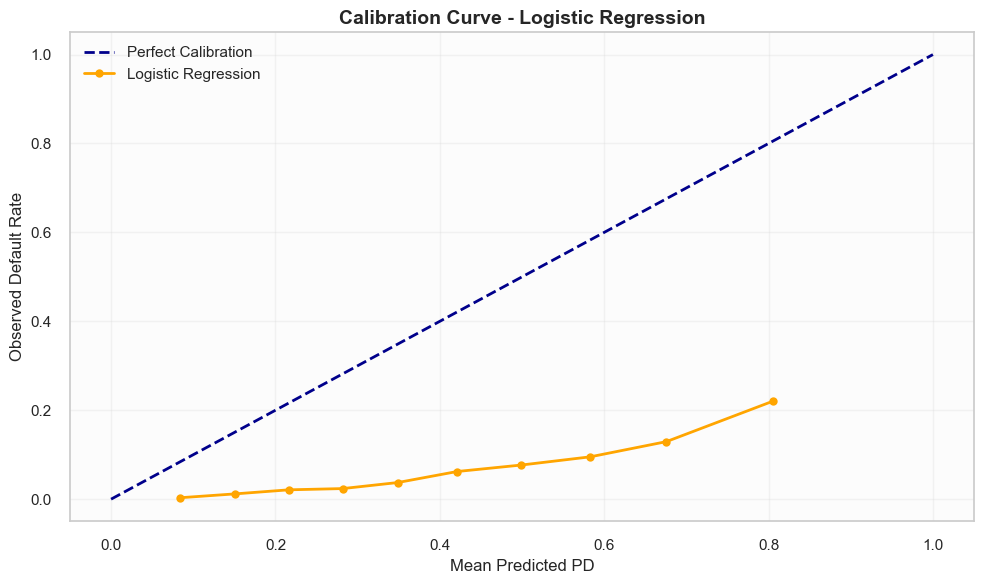

In [373]:
# Plot calibration curve (reliability diagram) for PD model evaluation.
def plot_calibration(model, X_test, y_test, model_name, n_bins, strategy):
    """
    Checks if predicted PD probabilities match actual default rates. A well-calibrated model should follow the diagonal line closely.
    """
    prob_true, prob_pred = calibration_curve(y_test_1d, cw_y_pred_proba, n_bins=n_bins, strategy=strategy)
    fig, ax = plt.subplots(figsize=(10, 6))
    # Perfect calibration line
    ax.plot([0, 1], [0, 1], linestyle='--', color='darkblue', linewidth=2, label='Perfect Calibration')
    # Model calibration curve
    ax.plot(prob_pred, prob_true, marker='o', color='orange', linewidth=2, label=model_name)

    # Formatting
    ax.set_xlabel("Mean Predicted PD", fontsize=12)
    ax.set_ylabel("Observed Default Rate", fontsize=12)
    ax.set_title(f"Calibration Curve - {model_name}", fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
plot_calibration(model=logit_cw, X_test=X_test_encoded, y_test=y_test, model_name="Logistic Regression", n_bins=10, strategy='quantile')

**Model Calibration Assessment**

Before calibration, the class‑weighted logistic regression consistently predicts probabilities of default (PDs) that are **significantly higher** than the observed default rates – a classic sign of an **over‑conservative** model.

- **Discrimination** (ROC‑AUC) is reasonable → the model ranks risk well.
- **Probability estimation** is poor → predicted PDs are systematically biased upward.

This overestimation means the model would:
- Reject many good customers unnecessarily (**credit rationing**)
- Distort risk‑based pricing and capital allocation

**Solution**: Two calibration methods are applied to transform the raw predictions, minimising the **Mean Absolute Calibration Error (MACE)**. Calibration adjusts the predicted probabilities so that Predicted PD ≈ Observed Default Rate
- 1. Platt Scaling (Sigmoid)
- 2. Isotonic Regression

In [374]:
# PLATT SCALING (SIGMOID CALIBRATION) - fits a logistic function to transform the original predicted probabilities.
# -----------------------------------------------------------------------------------------------
sigmoid_model = CalibratedClassifierCV(estimator=logit_cw, method='sigmoid', cv=5)
# Fit the calibration model using the training data
sigmoid_model.fit(X_train_encoded, y_train.values.ravel())
# Generate calibrated probabilities on the test set
sigmoid_predict_proba = sigmoid_model.predict_proba(X_test_encoded)[:, 1]

# ISOTONIC REGRESSION CALIBRATION - fits a non-parametric isotonic regression model to adjust predicted probabilities, allowing for more flexible calibration (capture non-linear relationships between predicted probabilities and observed outcomes).
isotonic_model = CalibratedClassifierCV(estimator=logit_cw, method='isotonic', cv=5)
# Fit isotonic calibration using the training data
isotonic_model.fit(X_train_encoded, y_train.values.ravel())
# Generate calibrated probabilities for the test set
isotonic_predict_proba = isotonic_model.predict_proba(X_test_encoded)[:, 1]

,Metric,Sigmoid (Platt),Isotonic Regression
0,Applied Threshold,0.43,0.43
1,Youden's Index,0.02,0.00
2,ROC-AUC,0.77,0.77
3,Gini Index,0.53,0.53
4,F1 Score,0.03,0.01
5,Recall,0.02,0.00
6,Precision,0.36,0.38



 Classification Report: Sigmoid (Platt) (Test Set - Threshold = 0.4330)
                         precision    recall  f1-score   support

Non-Event (Not Default)     0.9328    0.9976    0.9641     46592
        Event (Default)     0.3584    0.0182    0.0346      3408

               accuracy                         0.9309     50000
              macro avg     0.6456    0.5079    0.4994     50000
           weighted avg     0.8937    0.9309    0.9008     50000


 Classification Report: Isotonic Regression (Test Set - Threshold = 0.4330)
                         precision    recall  f1-score   support

Non-Event (Not Default)     0.9320    0.9996    0.9646     46592
        Event (Default)     0.3750    0.0035    0.0070      3408

               accuracy                         0.9317     50000
              macro avg     0.6535    0.5015    0.4858     50000
           weighted avg     0.8941    0.9317    0.8993     50000



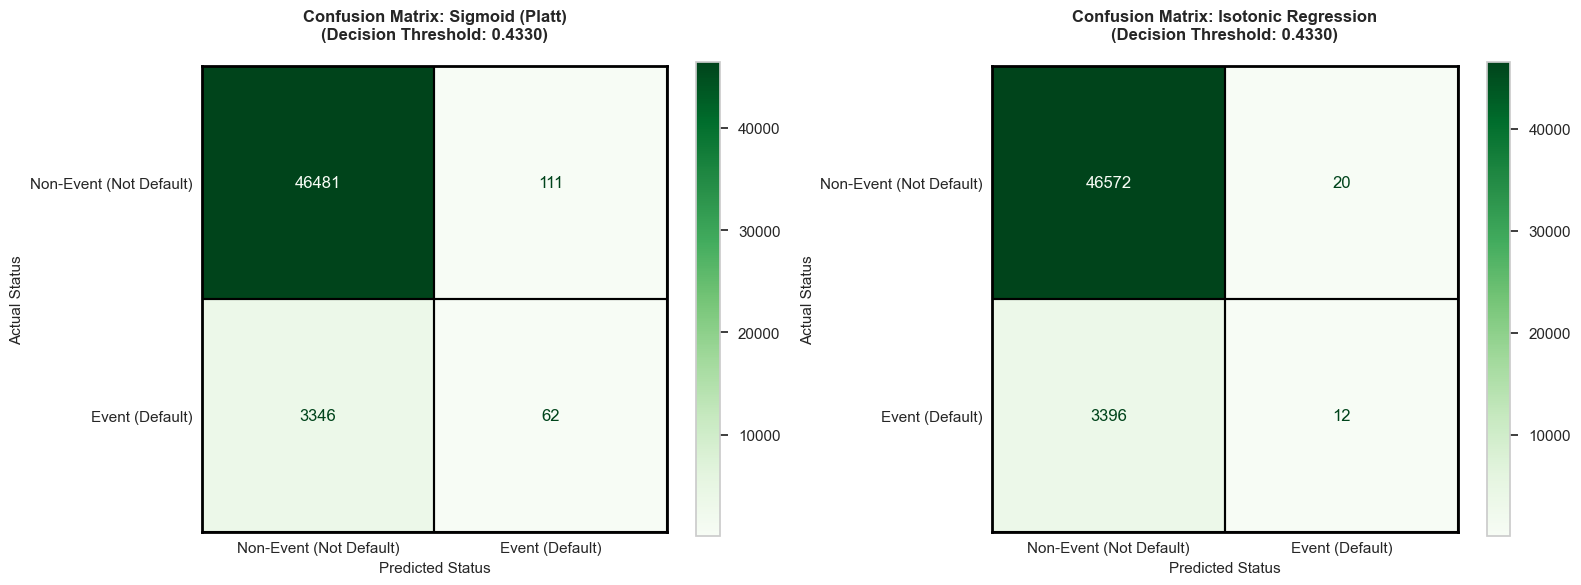

In [375]:
# Dictionary to hold probabilities for iteration
calibrated_models = {
    "Sigmoid (Platt)": sigmoid_predict_proba,
    "Isotonic Regression": isotonic_predict_proba
}

# Process Thresholds and Build Performance Summary Table
# -----------------------------------------------------------------------------------------------
summary_data = {
    "Metric": ["Applied Threshold", "Youden's Index", "ROC-AUC", "Gini Index", "F1 Score", "Recall", "Precision"]
}

# Store predictions and thresholds for the plots and reports
optimized_preds = {}
optimal_thresholds = {}

for name, probs in calibrated_models.items():
    # Generate predictions based on your pre-calculated ROS optimal threshold
    preds = (probs >= ros_optimal_threshold).astype(int)
    
    # Save for later visual outputs
    optimized_preds[name] = preds
    optimal_thresholds[name] = ros_optimal_threshold
    
    # Calculate complete ROC curve arrays to extract the specific Youden's Index at your threshold
    fpr, tpr, thresholds = roc_curve(y_test, probs)
    # Find the index closest to your specified threshold value
    closest_idx = np.argmin(np.abs(thresholds - ros_optimal_threshold))
    specific_youden_index = tpr[closest_idx] - fpr[closest_idx]
    
    # Calculate metrics
    auc = roc_auc_score(y_test, probs)
    gini = 2 * auc - 1
    
    summary_data[name] = [
        round(ros_optimal_threshold, 4),
        round(specific_youden_index, 4),
        round(auc, 4),
        round(gini, 4),
        round(f1_score(y_test, preds), 4),
        round(recall_score(y_test, preds), 4),
        round(precision_score(y_test, preds), 4)
    ]

performance_summary = pd.DataFrame(summary_data)
display(performance_summary)

# Print Classification Reports
# -----------------------------------------------------------------------------------------------
for name, preds in optimized_preds.items():
    thresh = optimal_thresholds[name]
    print("\n" + "="*80)
    print(f" Classification Report: {name} (Test Set - Threshold = {thresh:.4f})")
    print("="*80)
    print(classification_report(y_test, preds, target_names=["Non-Event (Not Default)", "Event (Default)"], digits=4))

# Plot Side-by-Side Confusion Matrices
# -----------------------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, preds) in zip(axes, optimized_preds.items()):
    thresh = optimal_thresholds[name]
    cm = confusion_matrix(y_test, preds)
    
    # Display confusion matrix with green color map
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, 
        display_labels=["Non-Event (Not Default)", "Event (Default)"]
    )
    disp.plot(cmap='Greens', ax=ax, colorbar=True)
    
    # Remove default grid
    ax.grid(False)
    
    # Add clear black borders around each cell
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='black', linewidth=1.5))
            
    # Add strong outer border (spines)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_edgecolor('black')
        
    # Title and Formatting
    ax.set_title(f"Confusion Matrix: {name}\n(Decision Threshold: {thresh:.4f})", 
                 pad=20, fontsize=12, fontweight='bold')
    ax.set_xlabel("Predicted Status", fontsize=11)
    ax.set_ylabel("Actual Status", fontsize=11)
    ax.tick_params(axis='both', which='both', length=0)

plt.tight_layout()
plt.show()

In [376]:
# Calibration Evaluation Function
# -----------------------------------------------------------------------------------------------
def calibration_summary(y_true, y_prob, model_name, n_bins=10):
    # strategy="quantile" ensures each bin contains approximately the same number of observations.
    # prob_pred = average predicted PD in each bin
    # prob_true = actual observed default rate in each bin
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy="quantile")
    # Calculate calibration error for each bin.
    calibration_error = prob_true - prob_pred
    #Calculate Mean Absolute Calibration Error (MACE)
    mean_abs_error = np.mean(np.abs(calibration_error))

    # Create a summary table:
    summary = pd.DataFrame({
        "Mean Predicted PD": np.round(prob_pred, 4),
        "Observed Default Rate": np.round(prob_true, 4),
        "Calibration Error": np.round(calibration_error, 4)})

    print(model_name.upper())
    print("-" * 100)

    # Calculate and display Brier Score (measures the mean squared difference between predicted probabilities and actual outcomes, lower is better)
    print(f"Brier Score                : {brier_score_loss(y_true, y_prob):.4f}")
    print(f"Mean Absolute Calib Error  : {mean_abs_error:.4f}")
    display(summary)

    return summary, mean_abs_error

$$\text{BS} = \frac{1}{N} \sum_{i=1}^{N} (p_i - y_i)^2$$
Where:
- $N$ = total number of observations
- $f_i$ = predicted probability of the event (e.g., default) for observation 
- $o_i$ = actual outcome: 1 if the event occurred, 0 otherwise

| Brier Score Range | Calibration Quality | Interpretation for PD Models |
| :--- | :--- | :--- |
| **< 0.01** | Excellent | Near‑perfect probability estimation – extremely rare |
| **0.01 – 0.05** | Good | Very well calibrated; suitable for regulatory capital calculations (Basel/IFRS9). |
| **0.05 – 0.10** | Acceptable | Moderate calibration – may still work for scorecard ranking but not for exact PDs. |
| **0.10 – 0.20** | Poor | Significant miscalibration – use only for ordinal ranking; apply post‑hoc calibration. |
| **> 0.20** | Very poor | Worse than predicting the base default rate for all observations – model is unreliable. |

In [377]:
# Calibration Comparison
# -----------------------------------------------------------------------------------------------
# Original class-weighted logistic regression probabilities.
cw_summary, cw_mace = calibration_summary(y_test, cw_y_pred_proba, "Original Class-Weighted Logistic Regression")

# Platt Scaling model
sig_summary, sig_mace = calibration_summary(y_test, sigmoid_predict_proba, "Platt Scaling (Sigmoid)")

# Isotonic Regression model.
iso_summary, iso_mace = calibration_summary(y_test, isotonic_predict_proba, "Isotonic Regression")

ORIGINAL CLASS-WEIGHTED LOGISTIC REGRESSION
----------------------------------------------------------------------------------------------------
Brier Score                : 0.2009
Mean Absolute Calib Error  : 0.3385


,Mean Predicted PD,Observed Default Rate,Calibration Error
0,0.08,0.00,-0.08
1,0.15,0.01,-0.14
2,0.22,0.02,-0.20
3,0.28,0.02,-0.26
4,0.35,0.04,-0.31
5,0.42,0.06,-0.36
6,0.50,0.08,-0.42
7,0.58,0.10,-0.49
8,0.68,0.13,-0.55
9,0.81,0.22,-0.59


PLATT SCALING (SIGMOID)
----------------------------------------------------------------------------------------------------
Brier Score                : 0.0594
Mean Absolute Calib Error  : 0.0052


,Mean Predicted PD,Observed Default Rate,Calibration Error
0,0.01,0.00,-0.00
1,0.01,0.01,-0.00
2,0.02,0.02,-0.00
3,0.03,0.02,-0.01
4,0.04,0.04,-0.00
5,0.05,0.06,0.01
6,0.07,0.08,0.01
7,0.09,0.10,0.00
8,0.13,0.13,0.00
9,0.23,0.22,-0.01


ISOTONIC REGRESSION
----------------------------------------------------------------------------------------------------
Brier Score                : 0.0593
Mean Absolute Calib Error  : 0.0031


,Mean Predicted PD,Observed Default Rate,Calibration Error
0,0.00,0.00,-0.00
1,0.01,0.01,0.00
2,0.02,0.02,0.00
3,0.03,0.03,-0.00
4,0.04,0.04,-0.00
5,0.06,0.06,0.01
6,0.08,0.08,0.00
7,0.10,0.10,-0.01
8,0.14,0.13,-0.01
9,0.22,0.22,0.00


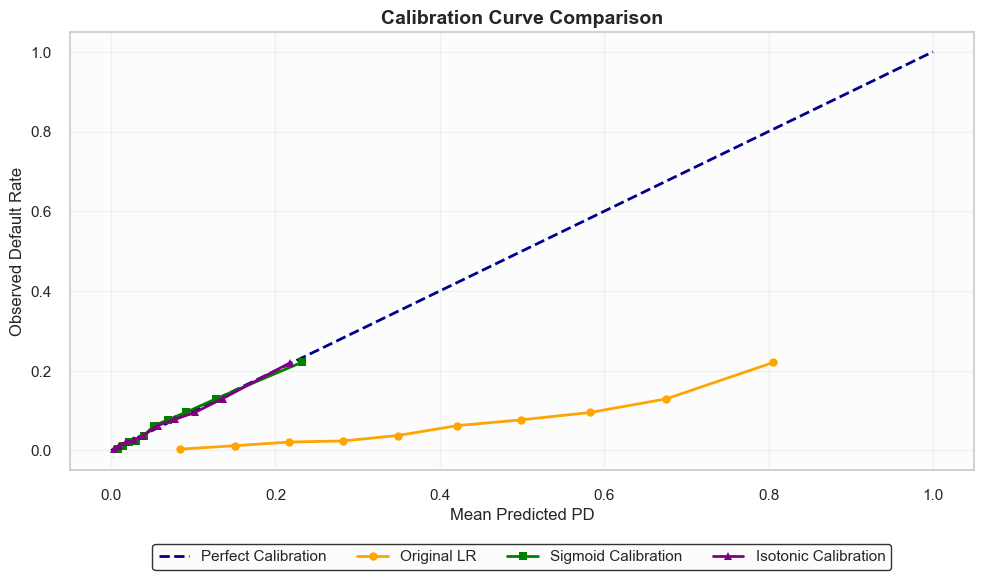

In [378]:
# Reliability Diagram Comparison
# -----------------------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

# Perfect Calibration Reference Line (The closer a model's curve is to this line, the better calibrated its probability estimates are.)
plt.plot([0, 1], [0, 1], linestyle="--", color='darkblue', linewidth=2, label="Perfect Calibration")

# Original Class-Weighted Logistic Regression
prob_true, prob_pred = calibration_curve(y_test, cw_y_pred_proba, n_bins=10, strategy="quantile")
plt.plot(prob_pred, prob_true, marker="o", color='orange', linewidth=2, label="Original LR")

# Sigmoid (Platt Scaling) Calibration
prob_true, prob_pred = calibration_curve(y_test, sigmoid_predict_proba, n_bins=10, strategy="quantile")
plt.plot(prob_pred, prob_true, marker="s", color='green', linewidth=2, label="Sigmoid Calibration")

# Isotonic Regression Calibration
prob_true, prob_pred = calibration_curve(y_test, isotonic_predict_proba, n_bins=10, strategy="quantile")
plt.plot(prob_pred, prob_true, marker="^", color='purple', linewidth=2, label="Isotonic Calibration")

# Formatting
plt.title("Calibration Curve Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Mean Predicted PD")
plt.ylabel("Observed Default Rate")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=True, edgecolor="black")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [379]:
# Generate an individual credit score explanation for a single borrower. 
# This function translates a calibrated Probability of Default (PD) produced by the class-weighted logistic regression model into an 
# interpretable internal credit score. It also provides a breakdown of the contribution of each predictor to the borrower's risk profile.

def explain_credit_score(lr_model, X_row, sample_pd, factor, calibration_method, threshold, target_score, target_odds, pdo, min_score, max_score,):
    """
    Parameters
    ----------
    lr_model : fitted LogisticRegression (Trained class-weighted logistic regression model).
    X_row : Single observation containing the encoded predictor variables used by the model.
    sample_pd : Calibrated Probability of Default (PD) generated using either Isotonic Regression or Platt Scaling.
    factor : Scorecard scaling factor (B) used to convert log-odds into score points according to the scorecard design.
    calibration_method :Name of the probability calibration technique used (e.g. "Isotonic Regression" or "Platt Scaling").
    threshold : Optimal classification threshold used to determine whether the borrower is classified as Default or Not Default.
    target_score : Base score assigned at the target odds.
    target_odds : Base odds associated with the target score.
    pdo : Points-to-double-the-odds (PDO) scaling parameter.
    min_score : Minimum allowable credit score.
    max_score : Maximum allowable credit score.
    """
    # Score Calculation and Prediction Logic
    # ==========================================================
    final_score, _, _ = pd_to_score(
        pred_proba=sample_pd,
        target_score=target_score,
        target_odds=target_odds,
        pdo=pdo,
        min_score=min_score,
        max_score=max_score,
    )
    prediction_text = "Default" if sample_pd >= threshold else "Not Default"

    # Rating Logic
    if final_score >= 650:
        rating = "Excellent"
        rating_color = "#4ade80"
    elif final_score >= 550:
        rating = "Good"
        rating_color = "#60a5fa"
    elif final_score >= 450:
        rating = "Fair"
        rating_color = "#facc15"
    else:
        rating = "Poor"
        rating_color = "#fb7185"

    prediction_color = "#fb7185" if prediction_text == "Default" else "#4ade80"

    # Business Decision Logic
    if prediction_text == "Not Default":
        business_decision = "Approve (Acceptable Risk)"
        decision_color = "#4ade80"  # Clean Green
    else:
        business_decision = "Reject (High Risk)"
        decision_color = "#fb7185"  # Soft Red

    # Logistic Contributions
    # ==========================================================
    coefficients = lr_model.coef_[0]
    contributions = X_row.iloc[0].values * coefficients
    df_breakdown = pd.DataFrame(
        {
            "Feature": X_row.columns,
            "Value": X_row.iloc[0].values,
            "Coefficient": coefficients,
            "Log-Odds Impact": contributions,
        }
    )

    # Score impact
    df_breakdown["Point Impact"] = -factor * df_breakdown["Log-Odds Impact"]

    # Impact direction
    df_breakdown["Impact Type"] = np.where(df_breakdown["Log-Odds Impact"] > 0, "❌ Increased Default Risk", "✅ Reduced Default Risk")

    # Absolute importance
    df_breakdown["Abs_Impact"] = df_breakdown["Point Impact"].abs()

    # Rank drivers by magnitude
    df_breakdown = (df_breakdown.sort_values("Abs_Impact", ascending=False).reset_index(drop=True))

    # Calculate Raw Model PD to prevent NameError in HTML formatting
    # ==========================================================
    raw_pd = lr_model.predict_proba(X_row)[0][1]

    # HEADER CARD
    # ==========================================================
    html_content = f"""
    <div style="border:2px solid #4ade80; padding:25px; background-color:#1a1a1a; border-radius:10px; margin-bottom:25px; font-family:sans-serif;">
        
        <h2 style="margin: 0 0 15px 0; color:#4ade80; letter-spacing:2px; font-size:20px;">
            INTERNAL SCORE AUDIT
        </h2>
        
        <p style="font-size:18px; color:white; margin:0 0 12px 0; line-height:1.6; letter-spacing:0.5px;">
            Final Score: <b style="color:#60a5fa; font-size:26px; letter-spacing:1px;">{final_score:.0f}</b>
            <span style="margin:0 15px; color:#4b5563;">|</span>
            <span style="background-color:{rating_color}; color:#0f172a; padding:5px 16px; border-radius:20px; font-weight:bold; letter-spacing:0.5px;">{rating}</span>
        </p>
        
        <p style="color:#d1d5db; margin:0 0 15px 0; line-height:1.6; letter-spacing:0.5px;">
            Calibration: <b style="color:#93c5fd; letter-spacing:0.5px;">{calibration_method}</b>
        </p>

        <ul style="list-style: none; padding: 0; margin: 0 0 15px 0; color: white;">
            <li style="display: flex; align-items: center; margin: 8px 0;">
                <span style="color: #4ade80; margin-right: 10px;">•</span>
                <span style="width: 150px; display: inline-block;">Decision Threshold</span>
                <span>: <b style="color: #93c5fd;">{threshold:.4f}</b></span>
            </li>
            <li style="display: flex; align-items: center; margin: 8px 0;">
                <span style="color: #4ade80; margin-right: 10px;">•</span>
                <span style="width: 150px; display: inline-block;">Calibrated PD</span>
                <span>: <b style="color: #fb7185;">{sample_pd:.4f}</b> <span style="color: #6b7280; font-size: 14px;">({calibration_method})</span></span>
            </li>
            <li style="display: flex; align-items: center; margin: 8px 0;">
                <span style="color: #4ade80; margin-right: 10px;">•</span>
                <span style="width: 150px; display: inline-block;">Raw Model PD</span>
                <span>: <b style="color: #fca5a5;">{raw_pd:.4f}</b> <span style="color: #6b7280; font-size: 14px;">(Pre-Calibration)</span></span>
            </li>
        </ul>

        <p style="color:#9ca3af; margin:0; line-height:1.6; letter-spacing:0.5px;">
            Prob. of Default: <b style="color:#f87171; letter-spacing:0.5px;">{sample_pd:.4%}</b>
            <span style="margin:0 15px; color:#4b5563;">|</span>
            Prediction: <b style="color:{prediction_color}; letter-spacing:0.5px;">{prediction_text}</b>
            <span style="margin:0 15px; color:#4b5563;">|</span>
            Decision: <b style="color:{decision_color}; letter-spacing:0.5px;">{business_decision}</b>
        </p>
        
    </div>
    """
    display(HTML(html_content))

    return df_breakdown

In [380]:
# Select the row index for explanation (0-based index)
sample_idx = 0

# Run the explanation function
explanation_df = explain_credit_score(
    lr_model=logit_cw,
    X_row=X_test_encoded.iloc[[sample_idx]],
    sample_pd=sigmoid_predict_proba[sample_idx],
    factor=factor,
    calibration_method="Sigmoid Regression",
    threshold=cw_optimal_threshold,
    target_score=600,
    target_odds=20,
    pdo=20,
    min_score=200,
    max_score=800,)

# Preview top 20
print("\n📊 DATAFRAME VIEW (TOP 20 DRIVERS):")
display(explanation_df.head(20))


📊 DATAFRAME VIEW (TOP 20 DRIVERS):


,Feature,Value,Coefficient,Log-Odds Impact,Point Impact,Impact Type,Abs_Impact
0,mths_since_issue_d,-1.61,0.77,-1.23,35.61,✅ Reduced Default Risk,35.61
1,int_rate,-0.92,0.53,-0.49,14.19,✅ Reduced Default Risk,14.19
2,int_rate_tier_L (5 - 11%),True,-0.17,-0.17,4.86,✅ Reduced Default Risk,4.86
3,installment,-1.21,0.11,-0.13,3.77,✅ Reduced Default Risk,3.77
4,verification_status_Source Verified,True,0.09,0.09,-2.47,❌ Increased Default Risk,2.47
5,funded_amnt,-1.21,0.07,-0.09,2.45,✅ Reduced Default Risk,2.45
6,inq_last_6mths,-0.62,0.14,-0.08,2.44,✅ Reduced Default Risk,2.44
7,initial_list_status_w,True,-0.04,-0.04,1.25,✅ Reduced Default Risk,1.25
8,tot_cur_bal,-0.57,-0.07,0.04,-1.09,❌ Increased Default Risk,1.09
9,mths_since_last_delinq,-0.72,-0.04,0.03,-0.81,❌ Increased Default Risk,0.81


# Saving model and notebook

In [381]:
import pickle

# Create a dedicated folder for the models if it doesn't exist
target_directory = r"C:\Users\danie\Downloads\Data Analytic\lending_club_data\model_deployment"

if not os.path.exists(target_directory):
    os.makedirs(target_directory)
    print(f"✅ Created directory: {target_directory}")
else:
    print(f"📂 Directory already exists: {target_directory}")

# Define the full file path for the model and csv
model_path = os.path.join(target_directory, "credit_risk_pd_model.pkl")
results_path = os.path.join(target_directory, "credit_risk_pd_model.csv")

# Explicitly apply the optimal threshold to get the correct class predictions. This ensures Precision, Recall, and F1 are calculated on custom operational threshold!
cw_y_pred_optimized = (cw_y_pred_proba >= cw_optimal_threshold).astype(int)

# Consolidate model, scaling factors, and feature names
model_data = {
    # Main PD model
    "model": logit_cw,
    # Calibration model
    "calibration_model": sigmoid_model,
    # Optimal classification threshold
    "optimal_threshold": cw_optimal_threshold,
    # Scorecard scaling parameters
    "factor": factor,
    "offset": offset,
    # Scorecard configuration
    "target_score": 600,
    "target_odds": 20,
    "pdo": 20,
    "min_score": 200,
    "max_score": 800,
    # Feature metadata lists
    "feature_names": X_test_encoded.columns.tolist(),
    # Model performance metrics
    "roc_auc": roc_auc_score(y_test, cw_y_pred_proba),
    
    "f1_score": f1_score(y_test, cw_y_pred_optimized),
    "recall": recall_score(y_test, cw_y_pred_optimized),
    "precision": precision_score(y_test, cw_y_pred_optimized)}


# Save using Pickle
try:
    with open(model_path, 'wb') as file:
        pickle.dump(model_data, file)
    print(f"🚀 Success! Model saved to:\n{model_path}")
except Exception as e:
    print(f"❌ An error occurred while saving: {e}")


# Save the Results using CSV
try:
    scoring_df = scoring_df.reset_index(drop=True)
    scoring_df.to_csv(results_path, index=False)
    print(f"📊 Success! Scoring results CSV saved to:\n{results_path}")
except Exception as e:
    print(f"❌ Error saving scoring results CSV: {e}")

📂 Directory already exists: C:\Users\danie\Downloads\Data Analytic\lending_club_data\model_deployment
🚀 Success! Model saved to:
C:\Users\danie\Downloads\Data Analytic\lending_club_data\model_deployment\credit_risk_pd_model.pkl
📊 Success! Scoring results CSV saved to:
C:\Users\danie\Downloads\Data Analytic\lending_club_data\model_deployment\credit_risk_pd_model.csv


In [382]:
# Create the master export DataFrame by pulling extra analytical fields from your original X_test
pd_master_export = pd.DataFrame({
    'Probability_of_Default (PD)': ros_y_pred_proba,
    'Actual_Default_Status': y_test_flat,
    
    # Safely extract original features using the matching index
    'funded_amnt': X_test.loc[X_test_encoded.index, 'funded_amnt'],
    'int_rate': X_test.loc[X_test_encoded.index, 'int_rate'],
    'fico_mean': X_test.loc[X_test_encoded.index, 'fico_mean'],
    'term': X_test.loc[X_test_encoded.index, 'term']
}, index=X_test_encoded.index)

# Export to Deployment Path
master_export_path = os.path.join(target_directory, "pd_predictions_full_test.csv")
try:
    pd_master_export.to_csv(master_export_path, index=True)
    print("=" * 100)
    print(f"📂 Deployed Path  : {master_export_path}")
    print(f"📊 Matrix Profile: {pd_master_export.shape[0]:,} accounts | {pd_master_export.shape[1]} metrics")
    print("=" * 100)
except Exception as e:
    print(f"❌ Structural Save Failure: {e}")

📂 Deployed Path  : C:\Users\danie\Downloads\Data Analytic\lending_club_data\model_deployment\pd_predictions_full_test.csv
📊 Matrix Profile: 50,000 accounts | 6 metrics


In [383]:
import shutil

# Define source and destination
current_notebook_name = "N02 - Modelling probability of default (PD) and scorecard.ipynb" 
destination_path = r"C:\Users\danie\Downloads\Data Analytic\lending_club_data\model_deployment"

# Ensure destination exists
if not os.path.exists(destination_path):
    os.makedirs(destination_path)

# Perform the copy
try:
    # This looks for the file in the current working directory
    shutil.copy(current_notebook_name, os.path.join(destination_path, current_notebook_name))
    print(f"✅ Notebook successfully copied to: {destination_path}")
except FileNotFoundError:
    print(f"❌ Error: Could not find '{current_notebook_name}'.")
    print("👉 Make sure the filename matches exactly and you have saved (Ctrl+S) recently.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

❌ An unexpected error occurred: 'N02 - Modelling probability of default (PD) and scorecard.ipynb' and 'C:\\Users\\danie\\Downloads\\Data Analytic\\lending_club_data\\model_deployment\\N02 - Modelling probability of default (PD) and scorecard.ipynb' are the same file


In [384]:
# Saves the scaled dataframe directly as a standard spreadsheet file
X_test_encoded.to_excel("X_test_encoded_output.xlsx", sheet_name="Scaled_Test_Data", index=False)